# Load data

In [1]:
from pathlib import Path
base_path = Path('..') / 'data' / 'processed'

In [2]:
import pandas as pd

# Construct full paths for the parquet files
jobs_file_path = f'{base_path}/jobs_cleaned.parquet'
skills_file_path = f'{base_path}/skills.parquet'

# Read the parquet files into pandas DataFrames
df_jobs = pd.read_parquet(jobs_file_path)
df_skills = pd.read_parquet(skills_file_path)

In [6]:
df_jobs['job_level_tier'].value_counts()

job_level_tier
Mid        1933
Lead        603
Senior      253
Manager     219
Unknown     141
Junior       32
Name: count, dtype: int64

In [7]:
display(df_jobs.head())

,job_id,url,job_title,company,location,salary,experience,education,job_level,employment_type,...,source,salary_raw,min_salary,max_salary,avg_salary,is_thoa_thuan,is_null_salary,is_missing_salary,experience_years,job_level_tier
0,1,https://www.topcv.vn/viec-lam/lap-trinh-vien-n...,Lập Trình Viên (.Net) - Không Yêu Cầu Kinh Ngh...,Công ty cổ phần công nghệ và giải pháp trực tu...,Hà Nội,8 - 20 triệu,2 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,...,topcv,8 - 20 triệu,8.0,20.0,14.0,False,False,False,2.0,Mid
1,2,https://www.topcv.vn/viec-lam/mobile-app-engin...,Mobile App Engineer ( IOS / Android ) – AI Gla...,CÔNG TY TNHH VEANIX,Hà Nội,Thỏa thuận,Trên 5 năm,Đại Học trở lên,Trưởng nhóm,Toàn thời gian,...,topcv,Thoả thuận,0.0,0.0,0.0,True,False,True,5.5,Lead
2,3,https://www.topcv.vn/viec-lam/backend-lead-eng...,Backend Lead Engineer,CÔNG TY TNHH LEVER SPHERE VIỆT NAM,Hà Nội,50 - 70 triệu,3 năm,Đại Học trở lên,Trưởng nhóm,Toàn thời gian,...,topcv,50 - 70 triệu,50.0,70.0,60.0,False,False,False,3.0,Lead
3,4,https://www.topcv.vn/viec-lam/lap-trinh-vien-n...,Lập Trình Viên Nodejs Đi Làm Ngay Tại Hà Nội,Công ty cổ phần giải pháp MKT,Hà Nội,Tới 30 triệu,1 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,...,topcv,Tới 30 triệu,0.0,30.0,30.0,False,False,False,1.0,Mid
4,5,https://www.topcv.vn/viec-lam/ky-su-tu-van-man...,Kỹ Sư Tư Vấn Mạng/ Presale Network Engineer,Công ty Cổ phần Viễn thông - Tin học Bưu điện ...,Hà Nội,Tới 45 triệu,3 năm,Cao Đẳng trở lên,Nhân viên,Toàn thời gian,...,topcv,Tới 45 triệu,0.0,45.0,45.0,False,False,False,3.0,Mid


In [12]:
display(df_skills.head())

,job_id,skill_name,final_canonical,label,category,level,min_years,source_text
0,1,ASP.NET,asp net core,required_skill,Framework / Library,None,<NA>,"Có hiểu biết về ASP.NET, OOP, RESFULL, Design ..."
1,1,OOP,oop,required_skill,Engineering Concepts & Methodologies,None,<NA>,"Có hiểu biết về ASP.NET, OOP, RESFULL, Design ..."
2,1,RESFULL,Engineering Concepts & Methodologies Other,required_skill,Engineering Concepts & Methodologies,None,<NA>,"Có hiểu biết về ASP.NET, OOP, RESFULL, Design ..."
3,1,Design Patterns,design patterns,required_skill,Engineering Concepts & Methodologies,None,<NA>,"Có hiểu biết về ASP.NET, OOP, RESFULL, Design ..."
4,1,lập trình Backend,backend development,required_skill,Domain Knowledge,None,<NA>,Có hiểu biết về lập trình Backend – Frontend


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, shapiro
import warnings
warnings.filterwarnings('ignore')

# --- Style chung cho tất cả plots trong notebook này ---
# Dùng style tối giản, publication-friendly
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# Palette nhất quán: TopCV=xanh dương, ITViec=cam
SOURCE_PALETTE = {'topcv': '#2563EB', 'itviec': '#EA580C'}
LEVEL_PALETTE  = sns.color_palette('viridis', 9)

print('Libraries loaded.')

Libraries loaded.


# Kiểm tra data

In [14]:
# --- Chuẩn hóa job_level sang thứ bậc có thể sort ---
LEVEL_ORDER = ['Junior', 'Mid', 'Senior', 'Lead', 'Manager']
df_jobs['level_cat'] = pd.Categorical(
    df_jobs['job_level'], categories=LEVEL_ORDER, ordered=True
)

# --- Tách working set: chỉ records có salary hợp lệ ---
# Loại 'Thoả thuận' và các trường hợp missing
df = df_jobs[~df_jobs['is_missing_salary']].copy()

print(f'Total records   : {len(df_jobs):,}')
print(f'Valid salary     : {len(df):,}  ({len(df)/len(df_jobs)*100:.1f}%)')
print(f'Missing/Thoa thuan: {df_jobs["is_missing_salary"].sum():,}')
print(f'\nSource breakdown (valid salary):')
source_counts = df['source'].value_counts()
source_pct = df['source'].value_counts(normalize=True) * 100
for source, count in source_counts.items():
    print(f'{source:<10} {count:>7,} ({source_pct[source]:.1f}%)')


Total records   : 3,181
Valid salary     : 1,476  (46.4%)
Missing/Thoa thuan: 1,705

Source breakdown (valid salary):
topcv        1,298 (87.9%)
itviec         178 (12.1%)


## Employment Type

In [101]:
# Overall employment type breakdown
print('Employment Type (Overall Dataset):')
overall_employment_type = df_jobs['employment_type'].value_counts(dropna=False)
overall_employment_type_pct = df_jobs['employment_type'].value_counts(dropna=False, normalize=True) * 100
for etype, count in overall_employment_type.items():
    print(f'{etype:<20} {count:>7,} ({overall_employment_type_pct[etype]:.1f}%)')

print('\nEmployment Type (TopCV):')
topcv_df = df_jobs[df_jobs['source'] == 'topcv']
topcv_employment_type = topcv_df['employment_type'].value_counts(dropna=False)
topcv_employment_type_pct = topcv_df['employment_type'].value_counts(dropna=False, normalize=True) * 100
for etype, count in topcv_employment_type.items():
    print(f'{etype:<20} {count:>7,} ({topcv_employment_type_pct[etype]:.1f}%)')

print('\nEmployment Type (ITViec):')
itviec_df = df_jobs[df_jobs['source'] == 'itviec']
itviec_employment_type = itviec_df['employment_type'].value_counts(dropna=False)
itviec_employment_type_pct = itviec_df['employment_type'].value_counts(dropna=False, normalize=True) * 100
for etype, count in itviec_employment_type.items():
    print(f'{etype:<20} {count:>7,} ({itviec_employment_type_pct[etype]:.1f}%)')


Employment Type (Overall Dataset):
Toàn thời gian         3,123 (98.2%)
Remote                    20 (0.6%)
Hybrid                    19 (0.6%)
Thời vụ                   10 (0.3%)
Khác                       5 (0.2%)
Bán thời gian              3 (0.1%)
Làm tại nhà                1 (0.0%)

Employment Type (TopCV):
Toàn thời gian         2,419 (99.1%)
Hybrid                     6 (0.2%)
Khác                       5 (0.2%)
Remote                     4 (0.2%)
Bán thời gian              3 (0.1%)
Thời vụ                    2 (0.1%)
Làm tại nhà                1 (0.0%)

Employment Type (ITViec):
Toàn thời gian           704 (95.0%)
Remote                    16 (2.2%)
Hybrid                    13 (1.8%)
Thời vụ                    8 (1.1%)


In [102]:
intern_jobs = df_jobs[df_jobs['employment_type'] == 'Bán thời gian']

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None, 'display.max_colwidth', None):
    display(intern_jobs[['url','job_title', 'job_level','employment_type', 'job_description', 'requirement']])

,url,job_title,job_level,employment_type,job_description,requirement
246,https://www.topcv.vn/viec-lam/nhan-vien-lap-trinh-part-time/2082992.html,Nhân Viên Lập Trình (Part-Time),Nhân viên,Bán thời gian,"3.1. Công việc Backend (BE) Tham gia phát triển và bảo trì hệ thống sử dụng C# – .NET Core. Xây dựng API, xử lý logic nghiệp vụ theo yêu cầu. Tối ưu hiệu năng và bảo mật hệ thống Backend. Phối hợp với Frontend để tích hợp và kiểm thử chức năng. 3.2. Công việc Frontend (FE) Phát triển giao diện người dùng bằng HTML, CSS, JavaScript, jQuery. Tối ưu trải nghiệm người dùng (UI/UX cơ bản). Kết nối API và xử lý dữ liệu hiển thị từ Backend. Sửa lỗi và cải tiến giao diện theo phản hồi thực tế. 3.3. Cơ sở dữ liệu (Database) Làm việc với SQL Server: thiết kế bảng, viết query, stored procedure. Tối ưu truy vấn và đảm bảo tính toàn vẹn dữ liệu. Hỗ trợ backup và bảo trì cơ sở dữ liệu khi cần. 3.4. Hỗ trợ các công việc khác Tham gia họp kỹ thuật, báo cáo tiến độ công việc. Viết tài liệu kỹ thuật cơ bản khi được yêu cầu. Thực hiện các nhiệm vụ khác theo phân công của quản lý.","4.1. Trình độ Sinh viên năm 2 trở lên hoặc tốt nghiệp Cao đẳng/Đại học chuyên ngành CNTT, Khoa học máy tính, Kỹ thuật phần mềm hoặc ngành liên quan. 4.2. Kỹ năng Có kiến thức nền tảng về lập trình hướng đối tượng (OOP) Thành thạo cơ bản: Backend: C#, .NET Core Frontend: HTML, CSS, JavaScript, jQuery Database: SQL Server Có khả năng đọc hiểu tài liệu kỹ thuật tiếng Anh. Tư duy logic tốt, khả năng tự học và giải quyết vấn đề. Có tinh thần trách nhiệm và chủ động trong công việc. 4.3. Kinh nghiệm Không yêu cầu kinh nghiệm; ưu tiên ứng viên đã từng làm dự án cá nhân, đồ án môn học hoặc thực tập liên quan đến .NET. Có sản phẩm demo hoặc GitHub là lợi thế."
875,https://www.topcv.vn/viec-lam/giao-vien-part-time-sinh-vien-nganh-cong-nghe-thong-tin-ky-thuat-dien-tu-tu-dong-hoa-hai-phong/1363980.html,Giáo Viên Part-Time - Sinh Viên Ngành Công Nghệ Thông Tin / Kỹ Thuật Điện Tử/ Tự Động Hoá [ Hải Phòng ],Nhân viên,Bán thời gian,"Giáo viên giảng dạy bộ môn Lập trình & phát triển ứng dụng. • Tham gia giảng dạy (hoặc trợ giảng) lập trình, sử dụng các ngôn ngữ: Python, Scratch, HTML, Mobile App, JAVASCRIPT, JAVA. Giáo viên giảng dạy bộ môn Điện tử tự động & Robot. Tham gia giảng dạy, trợ giảng đối với các môn học thuộc bộ môn điện tử – tự động hóa như: Lego Mindstorm, Arduino, Raspberry Pi... Giáo viên giảng dạy bộ môn Công nghệ 3D & Truyền thông đa phương tiện Tham gia giảng dạy, soạn giáo án, dựng khung chương trình, trợ giảng đối với các môn học thuộc bộ môn vẽ tay 3D, In 3D, Quay phim, Làm phim, Nhiếp ảnh....","Đang là sinh viên năm 2,3,4 đang theo học các chuyên ngành Công nghệ thông tin, Điện tử, Tự động hoá, Mỹ thuật,Toán,…. của các trường cao đẳng, đại học liên quan. Tốt nghiệp Đại học chuyên ngành Sư phạm, khoa công nghệ thông tin. Là giảng viên đã và đang giảng dạy tại các trường cấp 1, cấp 2 bộ môn Tin học, Công nghệ thông tin. Hoặc đang làm việc tại các công ty Truyền thông, Công nghệ thông tin."
2334,https://www.topcv.vn/viec-lam/part-time-it-brse-comtor/2023616.html,PART-TIME IT BrSE / COMTOR,Nhân viên,Bán thời gian,"1. Thông tin chung - Vị trí: Part-time IT BrSE / Comtor - Hình thức làm việc: Part-time - Địa điểm làm việc: Remote hoặc tại văn phòng (linh hoạt) - Thời gian làm việc: Tối thiểu 5 giờ / tuần 2. Mô tả công việc - Đóng vai trò cầu nối giao tiếp giữa khách hàng Nhật Bản và đội ngũ kỹ thuật tại Việt Nam. - Trao đổi, làm rõ yêu cầu nghiệp vụ và nội dung kỹ thuật với khách hàng bằng tiếng Nhật. - Hỗ trợ dịch thuật các tài liệu dự án như: đặc tả (spec), email, biên bản họp, báo cáo. - Tham gia các cuộc họp với khách hàng Nhật (online/offline), ghi nhận và truyền đạt yêu cầu cho team kỹ thuật. - Hỗ trợ giải thích tiến độ dự án, vấn đề kỹ thuật và kết quả phát triển cho khách hàng.","1.Yêu cầu về tiếng Nhật - Có khả năng giao tiếp lưu loát bằng tiếng Nhật (nghe – nói – đọc – viết). - Có ít nhất 2 năm kinh nghiệm làm IT BrSE hoặc Comtor trong các dự án phần mềm với k

In [87]:
intern_jobs = df_jobs[df_jobs['employment_type'] == 'Remote']

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None, 'display.max_colwidth', None):
    display(intern_jobs[['url','job_title', 'job_level','employment_type', 'job_description', 'requirement']])

url  \
24                         https://www.topcv.vn/viec-lam/chuyen-vien-trien-khai-he-thong-fluent-english/2085909.html   
254                              https://www.topcv.vn/viec-lam/c-c-desktop-application-developer-remote/2087927.html   
343                         https://www.topcv.vn/viec-lam/lead-software-engineer-desktop-remote-english/2094587.html   
1574                         https://www.topcv.vn/viec-lam/reporting-engineer-power-bi-microsoft-fabric/2081297.html   
2456                            https://itviec.com/it-jobs/agentic-coding-specialist-scandinavian-software-park-2937   
2467  https://itviec.com/it-jobs/ai-engineer-deep-learning-algorithm-engineer-edge-ai-visiontech-global-limited-3519   
2548                                      https://itviec.com/it-jobs/c-software-engineer-remote-mid-level-edge8-0327   
2607                https://itviec.com/it-jobs/data-engineer-ai-data-platform-japan-full-remote-salesnow-co-ltd-2945   
2727                          https://itviec.com/it-jobs/infrastructure-engineer-english-azure-cisco-four-hands-3706   
2763                           https://itviec.com/it-jobs/it-support-analyst-level-1-to-level-3-nexnode-pty-ltd-5423   
2777                   https://itviec.com/it-jobs/javascript-engineer-remote-cho-cong-ty-nhat-ban-neos-viet-nam-2759   
2787                      https://itviec.com/it-jobs/junior-ios-mobile-developer-swift-english-motorist-pte-ltd-0844   
2793                                                        https://itviec.com/it-jobs/junior-qa-engineer-oivan-4213   
2834                                     https://itviec.com/it-jobs/mid-senior-java-developer-saigon-technology-2604   
2847       https://itviec.com/it-jobs/middle-frontend-mobile-dev-react-react-native-vuiapp-by-nano-technologies-0751   
2911                             https://itviec.com/it-jobs/project-manager-banking-securities-domain-coderpush-0128   
2942                   https://itviec.com/it-jobs/remote-operations-analyst-aws-cloudwatch-orgscale-recruitment-1609   
2943                   https://itviec.com/it-jobs/remote-sr-react-native-engineer-reactjs-javascript-sourcecode-0435   
3126                        https://itviec.com/it-jobs/software-engineer-mobile-flutter-vincent-holdings-co-ltd-4904   
3136                          https://itviec.com/it-jobs/solution-architect-aws-azure-gcp-erp-togaf-fpt-digital-5149   

                                                    job_title  \
24           Chuyên Viên Triển Khai Hệ Thống (Fluent English)   
254             C++/C# Desktop Application Developer (Remote)   
343        Lead Software Engineer – Desktop (Remote, English)   
1574             Reporting Engineer Power BI Microsoft Fabric   
2456                                Agentic Coding Specialist   
2467     Remote AI Engineer (Deep Learning Algorithm/ Python)   
2548                C# Software Engineer [Remote - Mid Level]   
2607   Remote Data Engineer - AI Data Platform Japan (Python)   
2727          Infrastructure Engineer (English, Azure, Cisco)   
2763                  IT Support Analyst – Level 1 to Level 3   
2777        JavaScript Engineer (Remote cho công ty Nhật Bản)   
2787             Junior iOS Mobile Developer (Swift, English)   
2793                                       Junior QA Engineer   
2834                                Mid/Senior Java Developer   
2847      Middle Frontend Dev (React / React Native / Mobile)   
2911              Project Manager (Banking/Securities Domain)   
2942             Remote - Operations Analyst (AWS CloudWatch)   
2943  Remote -Sr. React Native Engineer (ReactJS, Javascript)   
3126                    Software Engineer (Mobile -  Flutter)   
3136         Solution Architect (AWS, Azure, GCP, ERP, TOGAF)   

               job_level employment_type  \
24             Nhân viên          Remote   
254            Nhân viên          Remote   
343          Trưởng nhóm          Remote   
1574           Nhân viên          Remote   
2456  

### Nhận xét

**Phân phối:** ~98% là `Toàn thời gian` (TopCV 99.1%, ITViec 95.0%) — near-zero variance. Minority classes (1–20 rows) quá nhỏ để model học được pattern.

**Vấn đề taxonomy:** cột này trộn 3 dimensions không cùng cấp:
- Schedule: `Toàn thời gian`, `Bán thời gian`
- Work mode (trùng cột `location`): `Remote`, `Hybrid`, `Làm tại nhà`
- Contract: `Thời vụ`

Platform không có ontology rõ ràng → không reliable làm feature.

**Quyết định:**
- Drop cột khỏi feature set của salary model (near-zero variance + mixed semantics).
- Filter scope về chỉ `Toàn thời gian` — salary structure của PT/Thời vụ/Remote khác fundamentally (hourly / project fee vs monthly), gộp chung sẽ violate giả định distribution của target.

## Experience

In [15]:
exp_values = (
    df_jobs["experience"]
    .astype(str)
    .str.strip()
)

print(f"Số giá trị unique: {exp_values.nunique()}")

for v in sorted(exp_values.unique()):
    print(repr(v))

Số giá trị unique: 32
'1 năm'
'1.5 năm'
'10 năm'
'12 năm'
'13 năm'
'2 năm'
'2.5 năm'
'3 năm'
'3.5 năm'
'4 năm'
'4.5 năm'
'5 năm'
'5.5 năm'
'6 năm'
'6.5 năm'
'7 năm'
'7.5 năm'
'8 năm'
'8.5 năm'
'9 năm'
'Dưới 1 năm'
'Không yêu cầu'
'Trên 1 năm'
'Trên 10 năm'
'Trên 2 năm'
'Trên 3 năm'
'Trên 4 năm'
'Trên 5 năm'
'Trên 6 năm'
'Trên 7 năm'
'Trên 8 năm'
'Trên 9 năm'


In [16]:
exp_stats = (
    df_jobs["experience_years"]
    .astype(str)
    .str.strip()
    .value_counts(dropna=False)
    .reset_index()
)

exp_stats.columns = ["experience_years", "count"]

print(exp_stats)

   experience_years  count
0               2.0    696
1               3.0    648
2               1.0    559
3               0.0    271
4               5.0    242
5               0.5    179
6               4.0    174
7               5.5    122
8               3.5    111
9               4.5     36
10              2.5     34
11              1.5     21
12              8.5     14
13              7.5     14
14              6.5     12
15              6.0     10
16             10.5      9
17              7.0      9
18              8.0      8
19             10.0      8
20             12.0      1
21              9.0      1
22             13.0      1
23              9.5      1


# Tỷ lệ thỏa thuận / null salary phân phối như nào

In [90]:
total = len(df_jobs)

# ── Đếm theo flag ─────────────────────────────────────────────────────────
n_thoa_thuan   = df_jobs['is_thoa_thuan'].sum()
n_null_salary  = df_jobs['is_null_salary'].sum()
n_missing      = df_jobs['is_missing_salary'].sum()   # union của 2 flag trên
n_valid        = total - n_missing

print(f"{'':30} {'n':>6}  {'%':>6}")
print("-" * 46)
print(f"{'Total records':<30} {total:>6}")
print(f"{'Thỏa thuận (có text, không số)':<30} {n_thoa_thuan:>6}  {n_thoa_thuan/total*100:>5.1f}%")
print(f"{'Null / missing salary':<30} {n_null_salary:>6}  {n_null_salary/total*100:>5.1f}%")
print(f"{'Tổng missing (union)':<30} {n_missing:>6}  {n_missing/total*100:>5.1f}%")
print(f"{'Valid (có số)':<30} {n_valid:>6}  {n_valid/total*100:>5.1f}%")

# ── Breakdown theo source ─────────────────────────────────────────────────
print("\n\nBreakdown theo source:")
print(f"\n{'Source':<10} {'Total':>7} {'Thỏa thuận':>12} {'Null':>8} {'Missing':>9} {'Valid':>7}")
print("-" * 58)
for src in ['topcv', 'itviec']:
    sub = df_jobs[df_jobs['source'] == src]
    n   = len(sub)
    tt  = sub['is_thoa_thuan'].sum()
    nu  = sub['is_null_salary'].sum()
    mis = sub['is_missing_salary'].sum()
    val = n - mis
    print(f"{src:<10} {n:>7} {tt:>9} ({tt/n*100:.0f}%) {nu:>5} ({nu/n*100:.0f}%) "
          f"{mis:>6} ({mis/n*100:.0f}%) {val:>5} ({val/n*100:.0f}%)")

                                    n       %
----------------------------------------------
Total records                    3181
Thỏa thuận (có text, không số)   1703   53.5%
Null / missing salary               2    0.1%
Tổng missing (union)             1705   53.6%
Valid (có số)                    1476   46.4%


Breakdown theo source:

Source       Total   Thỏa thuận     Null   Missing   Valid
----------------------------------------------------------
topcv         2440      1140 (47%)     2 (0%)   1142 (47%)  1298 (53%)
itviec         741       563 (76%)     0 (0%)    563 (76%)   178 (24%)


### Có 2 dòng bị missing salary (sẽ được loại bỏ khi build model)

In [91]:
import pandas as pd

# Thiết lập để Pandas không ẩn bớt cột khi in
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # Hiển thị full text trong mỗi ô nếu cần

# Lọc lấy 2 dòng bị Null salary
df_2_dong_null = df_jobs[df_jobs['is_null_salary'] == 1] # hoặc == True tùy kiểu dữ liệu của bạn

# In ra kết quả
print("\n\n--- CHI TIẾT 2 DÒNG NULL SALARY ---")
display(df_2_dong_null) # Dùng display() nếu bạn đang dùng Jupyter Notebook/Colab cho đẹp
# print(df_2_dong_null) # Nếu chạy file script .py bình thường thì dùng print



--- CHI TIẾT 2 DÒNG NULL SALARY ---


,job_id,url,job_title,company,location,salary,experience,education,job_level,employment_type,industry,platform_required_skills,platform_preferred_skills,specialization,job_description,requirement,standardized_title,source,salary_raw,min_salary,max_salary,avg_salary,is_thoa_thuan,is_null_salary,is_missing_salary,experience_years,level_cat
1019,1020,https://www.topcv.vn/viec-lam/brse-dao-tao-sap/1814704.html,BrSE ( Đào Tạo SAP),Công ty Cổ phần VNEXT SOFTWARE,Hà Nội,Tới 0.0 triệu,2 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,IT - Phần mềm,"['Kỹ năng giao tiếp', 'Kỹ năng làm việc nhóm', 'kỹ năng thuyết trình', 'Tiếng Nhật (n2 Trở Lên)', 'Tiếng Việt (thành Thạo)']",[],"['2 năm kinh nghiệm', 'Đại Học trở lên', 'Tiếng Nhật JLPT N2', 'Nghỉ thứ 7', 'Chuyên môn Công nghệ thông tin khác', 'IT - Phần mềm']","Được đào tạo về nghiệ vụ, kiến thức, kỹ năng lập trình cho hệ thống SAP từ 3-6 tháng trước khi join dự án. Là cầu nối giữa khách hàng Nhật Bản và đội dự án Offshore ở Việt Nam; Làm việc trực tiếp với khách hàng Nhật: giao tiếp, thương lượng, nhận, phân tích các yêu cầu của dự án phần mềm... và truyền đạt cho đội dự án ở Việt Nam; Có thể onsite ngắn hạn tại Nhật Bản.",Tốt nghiệp ĐH/CĐ chuyên ngành Công nghệ Thông tin hoặc các ngành khác có liên quan; Trình độ tiếng Nhật từ N2 trở lên (giao tiếp tốt); Có ít nhất 2 năm kinh nghiệm tham gia các dự án phát triển phần mềm và có kinh nghiệm lập trình với ÍT NHẤT MỘT ngôn ngữ ( .Net/ Java/ ReactJS/ Android/ iOS/ NodeJS...) Có ít nhất 01 năm kinh nghiệm ở vai trò tương đương (BrSE hoặc PM dự án) cho khách hàng Nhật; Ưu tiên : Ưu tiên ứng viên đã có kinh nghiệm làm việc tại Nhật (không bắt buộc).,Bridge Engineer,topcv,Tới 0.0 triệu,0.0,0.0,0.0,False,True,True,2.0,Nhân viên
1795,1796,https://www.topcv.vn/viec-lam/product-manager-generics-product-group/2075882.html,Product Manager – Generics Product Group,CÔNG TY TNHH SK QUỐC TẾ,Hồ Chí Minh,0.0 - 0.0 triệu,3 năm,Đại Học trở lên,Trưởng/Phó phòng,Toàn thời gian,Dược phẩm / Y tế / Công nghệ sinh học,"['Presentation Skill', 'Negotiation Skill', 'crisis management skill', 'Analytical skill', 'Teamwork']",[],"['3 năm kinh nghiệm', 'Đại Học trở lên', 'Tiếng Anh Đọc hiểu', 'Bảo hiểm xã hội', 'Khám sức khỏe định kỳ', 'Team building', 'Product Owner/Product Manager', 'Y tế / Dược phẩm']","I. ROLES & RESPONSIBILITIES:1. Planning / Business Development: Review and analyze overall market and sales trends for all products and therapy areas of generics group of our company Identify market insights and opportunities to decide the strategy of the product in the market. Design and carry out marketing programs established in accordance with national policies and market conditions. Lead and work with the cross-functional teams in devising and implementing brand strategy, activities, and campaigns Establish an optimized plan through sales forecasting and financial management Prepare launching plan of new products Liaise with manufacturers (RA, R&D, PV) to facilitate the launch of new products as well as other issues of products 2. Product Management Develop promotion and marketing materials to be utilized by field-force team Responsible for pricing strategy of products Responsible for all quotations to customers From the brand planning, cascade and communicate the programs, activities, and training to drive the brand performance Manage customer data (CRM) and update quarterly 3. Implementation and Monitoring Prepare & ensure implementation full year marketing plan, budget and timeline with regular review to update plan accordingly Continuously review and update the latest market trends and news to closely respond to the market and provide business insight. Provide product training and clear methods to sales team for better understanding to carry out the programs and action plans. Regularly analyze brand performance (monthly or quarter) and identifying the opportunities for improvement with the help field-force partners, managers, and key stakeholders. Devise action 

### Phân phối thỏa thuận

Tổng số records   : 3,181
Số 'thỏa thuận'   : 1,703  (53.5%)
Số có salary cụ thể: 1,478  (46.5%)

Theo nguồn (source):
        total_jobs  n_negotiable  pct_negotiable
source                                          
itviec         741           563       75.978408
topcv         2440          1140       46.721311


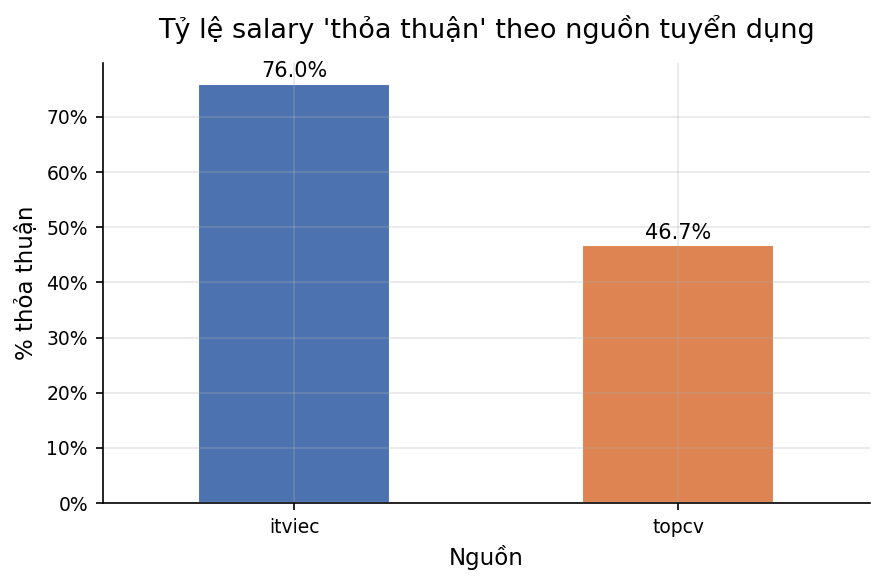

In [92]:
# ============================================================
# EDA — Kiểm tra cơ chế missing của salary thỏa thuận
# Bước 1: Univariate — nắm scale của is_thoa_thuan
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- 1.1 Tỷ lệ tổng thể ---
total = len(df_jobs)
n_negotiable = df_jobs["is_thoa_thuan"].sum()
pct = n_negotiable / total * 100

print("=" * 50)
print(f"Tổng số records   : {total:,}")
print(f"Số 'thỏa thuận'   : {n_negotiable:,}  ({pct:.1f}%)")
print(f"Số có salary cụ thể: {total - n_negotiable:,}  ({100 - pct:.1f}%)")
print("=" * 50)

# --- 1.2 Tách theo source (TopCV vs ITViec) ---
source_summary = (
    df_jobs.groupby("source")["is_thoa_thuan"]
    .agg(total_jobs="count", n_negotiable="sum")
    .assign(pct_negotiable=lambda x: x["n_negotiable"] / x["total_jobs"] * 100)
)
print("\nTheo nguồn (source):")
print(source_summary.to_string())

# --- 1.3 Visual: bar chart tỷ lệ theo source ---
fig, ax = plt.subplots(figsize=(6, 4))
source_summary["pct_negotiable"].plot(
    kind="bar", ax=ax, color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5
)
ax.set_title("Tỷ lệ salary 'thỏa thuận' theo nguồn tuyển dụng", fontsize=13, pad=12)
ax.set_xlabel("Nguồn", fontsize=11)
ax.set_ylabel("% thỏa thuận", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5),
        ha="center", va="bottom", fontsize=10
    )
plt.tight_layout()
plt.show()

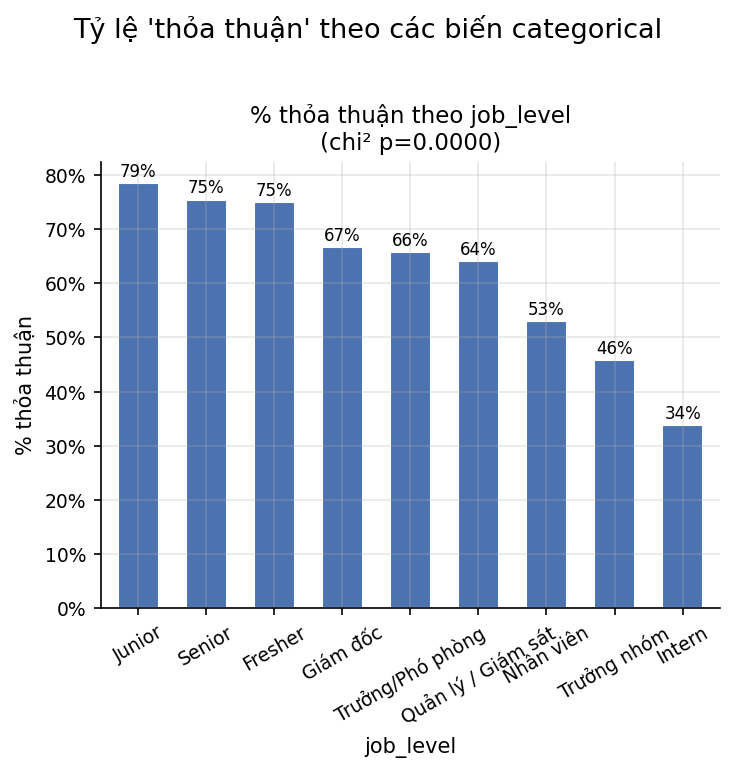


Chi-square test — H₀: is_thoa_thuan độc lập với biến (MCAR)
---------------------------------------------
  job_level        p = 0.0000   → *** BÁC BỎ MCAR


In [45]:
# ============================================================
# Bước 2 — Bivariate với biến CATEGORICAL
# ============================================================

from scipy.stats import chi2_contingency

# Định nghĩa các cột categorical cần kiểm tra
# Điều chỉnh list này cho đúng với tên cột thực tế trong df_jobs
CAT_COLS = ["job_level"]   # ← sửa nếu cần

def chi2_test(df, col, target="is_thoa_thuan"):
    """Trả về p-value chi-square giữa col và target."""
    ct = pd.crosstab(df[col], df[target])
    _, p, _, _ = chi2_contingency(ct)
    return p

fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(5 * len(CAT_COLS), 5))
if len(CAT_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, CAT_COLS):
    if col not in df_jobs.columns:
        print(f"[SKIP] Cột '{col}' không tồn tại trong df_jobs.")
        continue

    pct_by_group = (
        df_jobs.groupby(col)["is_thoa_thuan"].mean() * 100
    ).sort_values(ascending=False)

    p_val = chi2_test(df_jobs.dropna(subset=[col]), col)

    pct_by_group.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white", width=0.6)
    ax.set_title(f"% thỏa thuận theo {col}\n(chi² p={p_val:.4f})", fontsize=11)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("% thỏa thuận", fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=30)
    for bar in ax.patches:
        ax.annotate(
            f"{bar.get_height():.0f}%",
            (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5),
            ha="center", va="bottom", fontsize=8
        )

plt.suptitle("Tỷ lệ 'thỏa thuận' theo các biến categorical", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- In tổng hợp p-value ---
print("\nChi-square test — H₀: is_thoa_thuan độc lập với biến (MCAR)")
print("-" * 45)
for col in CAT_COLS:
    if col not in df_jobs.columns:
        continue
    p = chi2_test(df_jobs.dropna(subset=[col]), col)
    verdict = "*** BÁC BỎ MCAR" if p < 0.05 else "không đủ cơ sở bác bỏ MCAR"
    print(f"  {col:<15}  p = {p:.4f}   → {verdict}")

# Outlier

In [17]:
# ============================================================
#  SECTION 1 (REVISED) — OUTLIER DETECTION: MULTI-METHOD APPROACH
# ============================================================
# Vấn đề với threshold cố định: arbitrary, không reproducible.
# Solution: tính outlier threshold bằng nhiều phương pháp thống kê,
# so sánh, rồi biện luận chọn phương pháp phù hợp với data đặc tính
# (right-skewed, heavy-tail).

import numpy as np
import matplotlib.pyplot as plt

salary = df['avg_salary'].copy()
log_salary = np.log1p(salary)

# ====== METHOD 1: PERCENTILE-BASED ======
# Đơn giản, không assumption về distribution
p99   = salary.quantile(0.99)
p995  = salary.quantile(0.995)
p999  = salary.quantile(0.999)

# ====== METHOD 2: TUKEY'S IQR FENCE (raw scale) ======
# Q3 + k*IQR với k=1.5 (mild) hoặc k=3.0 (extreme)
# Vấn đề: assumption symmetric distribution → strict với right-skewed data
q1 = salary.quantile(0.25)
q3 = salary.quantile(0.75)
iqr_val = q3 - q1
tukey_mild_raw    = q3 + 1.5 * iqr_val   # k=1.5
tukey_extreme_raw = q3 + 3.0 * iqr_val   # k=3.0

# ====== METHOD 3: TUKEY TRÊN LOG-SCALE (RECOMMENDED) ======
# Vì salary lệch phải, áp dụng Tukey sau log-transform sẽ chính xác hơn
# (distribution gần symmetric trên log scale → IQR fence có ý nghĩa)
log_q1 = log_salary.quantile(0.25)
log_q3 = log_salary.quantile(0.75)
log_iqr = log_q3 - log_q1
tukey_log_upper = log_q3 + 1.5 * log_iqr
tukey_log_raw = np.expm1(tukey_log_upper)  # transform back về raw scale

# Tukey log-scale với k=3.0 (extreme outlier multiplier theo Tukey 1977)
log_salary = np.log1p(df['avg_salary'])
log_q1, log_q3 = log_salary.quantile([0.25, 0.75])
log_iqr = log_q3 - log_q1
tukey_log_k3 = np.expm1(log_q3 + 3.0 * log_iqr)

# ====== METHOD 4: MAD (Median Absolute Deviation) ======
# Robust với outliers (không bị outliers extreme kéo lệch)
# Modified z-score: |z| > 3.5 → outlier (Iglewicz & Hoaglin 1993)
median = salary.median()
mad = (salary - median).abs().median()
mad_threshold = median + 3.5 * mad / 0.6745

# ====== METHOD 5: DOMAIN CEILING ======
# Domain knowledge: lương IT VN tối đa thực tế ~150M (C-level startup)
domain_ceiling = 150

methods = {
    'p99':                              p99,
    'p99.5':                            p995,
    'p99.9':                            p999,
    'Tukey mild raw (Q3+1.5×IQR)':      tukey_mild_raw,
    'Tukey extreme raw (Q3+3×IQR)':     tukey_extreme_raw,
    'Tukey on log-scale (Q3+1.5×IQR)':  tukey_log_raw,
    'Tukey on log-scale (Q3+3.0×IQR)':  tukey_log_k3,
    'MAD (median + 3.5×MAD/0.6745)':    mad_threshold,
    'Domain ceiling (IT VN reality)':   domain_ceiling,
}

print('='*78)
print(f'{"Method":<40} {"Threshold (M)":>15} {"n loại":>8} {"% loại":>8}')
print('='*78)
for name, thr in methods.items():
    n_loai = (salary > thr).sum()
    pct = n_loai / len(salary) * 100
    print(f'{name:<40} {thr:>13.1f}   {n_loai:>7d}  {pct:>6.2f}%')
print('='*78)

Method                                     Threshold (M)   n loại   % loại
p99                                               75.0        14    0.95%
p99.5                                             86.1         8    0.54%
p99.9                                          19746.9         2    0.14%
Tukey mild raw (Q3+1.5×IQR)                       58.8        68    4.61%
Tukey extreme raw (Q3+3×IQR)                      85.0         8    0.54%
Tukey on log-scale (Q3+1.5×IQR)                  100.5         3    0.20%
Tukey on log-scale (Q3+3.0×IQR)                  306.5         2    0.14%
MAD (median + 3.5×MAD/0.6745)                     67.9        40    2.71%
Domain ceiling (IT VN reality)                   150.0         2    0.14%


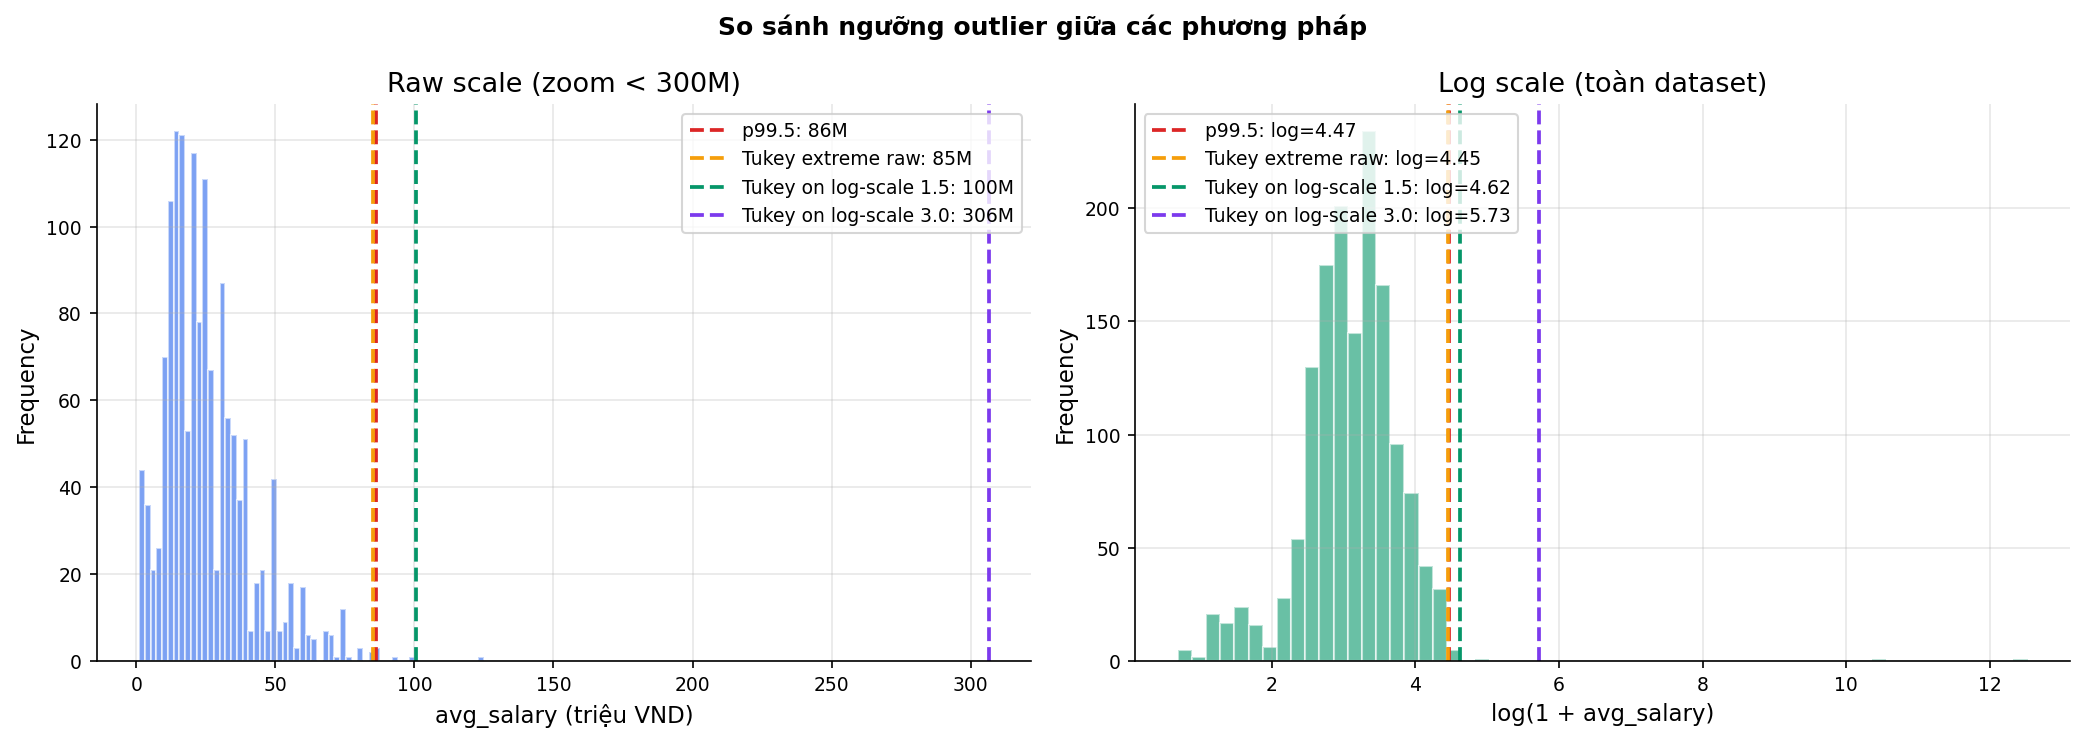

In [18]:
# ====== VISUALIZE: thresholds trên histogram raw vs log ======

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_method = {
    'p99.5':                p995,
    'Tukey extreme raw':    tukey_extreme_raw,
    'Tukey on log-scale 1.5':   tukey_log_raw,
    'Tukey on log-scale 3.0':   tukey_log_k3,
    'Domain ceiling':       domain_ceiling,
}
colors = ['#DC2626', '#F59E0B', '#059669', '#7C3AED']

# Left: raw scale (zoom dưới 300M để thấy rõ)
ax = axes[0]
ax.hist(salary[salary < 300], bins=60, color='#2563EB', alpha=0.6, edgecolor='white')
for (name, thr), color in zip(colors_method.items(), colors):
    ax.axvline(thr, color=color, linestyle='--', linewidth=1.8,
               label=f'{name}: {thr:.0f}M')
ax.set_xlabel('avg_salary (triệu VND)')
ax.set_ylabel('Frequency')
ax.set_title('Raw scale (zoom < 300M)')
ax.legend(fontsize=9, loc='upper right')

# Right: log scale
ax = axes[1]
ax.hist(log_salary, bins=60, color='#059669', alpha=0.6, edgecolor='white')
for (name, thr), color in zip(colors_method.items(), colors):
    ax.axvline(np.log1p(thr), color=color, linestyle='--', linewidth=1.8,
               label=f'{name}: log={np.log1p(thr):.2f}')
ax.set_xlabel('log(1 + avg_salary)')
ax.set_ylabel('Frequency')
ax.set_title('Log scale (toàn dataset)')
ax.legend(fontsize=9, loc='upper left')

fig.suptitle('So sánh ngưỡng outlier giữa các phương pháp', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outlier_methods_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [19]:
# ====== DECISION & JUSTIFICATION ======

# Phân tích trade-off của từng method:
#
# 1. Tukey raw (k=1.5):  loại ~5-7% records → quá strict, loại cả senior valid
# 2. Tukey raw (k=3.0):  loại ~1-2% → vẫn loại record 80M+ (lead/principal hợp lệ)
# 3. p99/p99.5/p99.9:    loại 0.5-1% → reasonable nhưng dependent on n
# 4. Tukey log-scale:    optimal theory cho skewed data → robust nhất
# 5. MAD:                robust nhưng vẫn strict với heavy-tail
# 6. Domain ceiling:     chỉ catch outlier extreme (USD errors)
#
# Final choice: TUKEY LOG-SCALE
# Lý do:
#   (a) Statistical sound: áp dụng Tukey trên scale mà data symmetric
#   (b) Reproducible: không phụ thuộc arbitrary number
#   (c) Loại được USD errors mà không drop valid high-salary records
#   (d) Cross-validate với p99.9 → 2 method cho threshold tương đồng
#
# Cross-check với domain: threshold final phải > p99.5 = 86M (preserve senior)
# Nếu Tukey log < 86M → fallback dùng max(Tukey log, p99.5)

final_threshold = max(tukey_log_k3, p995)

print(f'>>> FINAL THRESHOLD: {final_threshold:.1f} triệu VND')
print(f'    Phương pháp: max(Tukey log-scale, p99.5)')
print(f'    - Tukey log-scale: {tukey_log_raw:.1f}M')
print(f'    - p99.5 (safety floor): {p995:.1f}M')

df_clean = df[df['avg_salary'] <= final_threshold].copy()
print(f'\n=== Kết quả filter ===')
print(f'Trước: {len(df):,} records')
print(f'Sau:   {len(df_clean):,} records')
print(f'Loại:  {len(df) - len(df_clean)} records ({(len(df)-len(df_clean))/len(df):.2%})')

print(f'\n=== Records bị loại ===')
removed = df[df['avg_salary'] > final_threshold][['job_title', 'salary', 'avg_salary', 'source']]
print(removed.to_string())

>>> FINAL THRESHOLD: 306.5 triệu VND
    Phương pháp: max(Tukey log-scale, p99.5)
    - Tukey log-scale: 100.5M
    - p99.5 (safety floor): 86.1M

=== Kết quả filter ===
Trước: 1,476 records
Sau:   1,474 records
Loại:  2 records (0.14%)

=== Records bị loại ===
                                   job_title                       salary  avg_salary source
1602                         Chuyên Viên SRE            Tới 1,500,000 USD     37500.0  topcv
1848  Nhân Viên Idea Creator (Mảng POD - AI)  10,000,000 - 12,000,000 USD    275000.0  topcv


# Phân phối salary

In [20]:
# ============================================================
#  SECTION 2 — PHÂN PHỐI SALARY: THÔ vs LOG-TRANSFORM
# ============================================================
# Mục tiêu: chứng minh cần log-transform cho mô hình downstream

# Tính log-salary (log1p để tránh log(0) với min_salary=0)
df_clean['log_avg_salary'] = np.log1p(df_clean['avg_salary'])

# Shapiro-Wilk test cho cả hai (dùng sample nếu n > 5000, ở đây n~1476 nên OK)
stat_raw, p_raw   = shapiro(df_clean['avg_salary'])
stat_log, p_log   = shapiro(df_clean['log_avg_salary'])
skew_raw  = df_clean['avg_salary'].skew()
skew_log  = df_clean['log_avg_salary'].skew()
kurt_raw  = df_clean['avg_salary'].kurtosis()
kurt_log  = df_clean['log_avg_salary'].kurtosis()

print(f'         avg_salary  │  log(1+avg_salary)')
print(f'Skewness   {skew_raw:>+.3f}    │  {skew_log:>+.3f}')
print(f'Kurtosis   {kurt_raw:>+.3f}    │  {kurt_log:>+.3f}')
print(f'Shapiro p  {p_raw:.2e}   │  {p_log:.2e}')
print()
print('Interpretation:')
print(f'  - Raw salary: skewness={skew_raw:.2f} >> 1 → phân phối lệch phải mạnh')
print(f'  - Log salary: skewness={skew_log:.2f}   → gần đối xứng hơn đáng kể')
print(f'  - Kết luận: dùng log(1+salary) làm target variable cho regression model')

         avg_salary  │  log(1+avg_salary)
Skewness   +1.337    │  -0.748
Kurtosis   +2.675    │  +1.181
Shapiro p  1.35e-28   │  7.39e-19

Interpretation:
  - Raw salary: skewness=1.34 >> 1 → phân phối lệch phải mạnh
  - Log salary: skewness=-0.75   → gần đối xứng hơn đáng kể
  - Kết luận: dùng log(1+salary) làm target variable cho regression model


In [21]:
# Kiểm tra cluster ở giá trị thấp
import matplotlib.pyplot as plt

low_records = df_clean[df_clean['avg_salary'] < 10]
print(f"Records có avg_salary < 10M: {len(low_records)} ({len(low_records)/len(df_clean):.1%})")
print(f"\nBreakdown theo level:")
print(low_records['job_level'].value_counts())

# In chi tiết tất cả records lương thấp để verify
print(f"\n=== Chi tiết {len(low_records)} records có avg_salary < 10M ===")
cols_show = ['job_title', 'company', 'job_level', 'salary',
             'min_salary', 'max_salary', 'avg_salary', 'source']
# Sort theo avg_salary tăng dần để dễ scan từ thấp nhất
with pd.option_context('display.max_rows', None,
                       'display.max_colwidth', 50,
                       'display.width', 200):
    print(low_records[cols_show].sort_values('avg_salary').to_string())

# Pattern "Tới X triệu" → min_salary=0
toi_pattern = df_clean[df_clean['min_salary'] == 0]
print(f"\n\nRecords có min_salary=0 (dạng 'Tới X triệu'): {len(toi_pattern)} ({len(toi_pattern)/len(df_clean):.1%})")
print(f"Phân phối avg_salary của nhóm này:")
print(toi_pattern['avg_salary'].describe())

Records có avg_salary < 10M: 135 (9.2%)

Breakdown theo level:
job_level
Intern         101
Nhân viên       32
Trưởng nhóm      2
Name: count, dtype: int64

=== Chi tiết 135 records có avg_salary < 10M ===
                                                                                                                 job_title                                                                              company    job_level            salary  min_salary  max_salary  avg_salary source
792                                                                                                Thực Tập Sinh Front-End                                                       CÔNG TY CỔ PHẦN OKHUB VIỆT NAM       Intern        Từ 1 triệu         1.0         0.0        1.00  topcv
2184                                                                                                Thực Tập Sinh Kiểm Thử                                                              CÔNG TY CỔ PHẦN LIFETEX       Intern        Từ

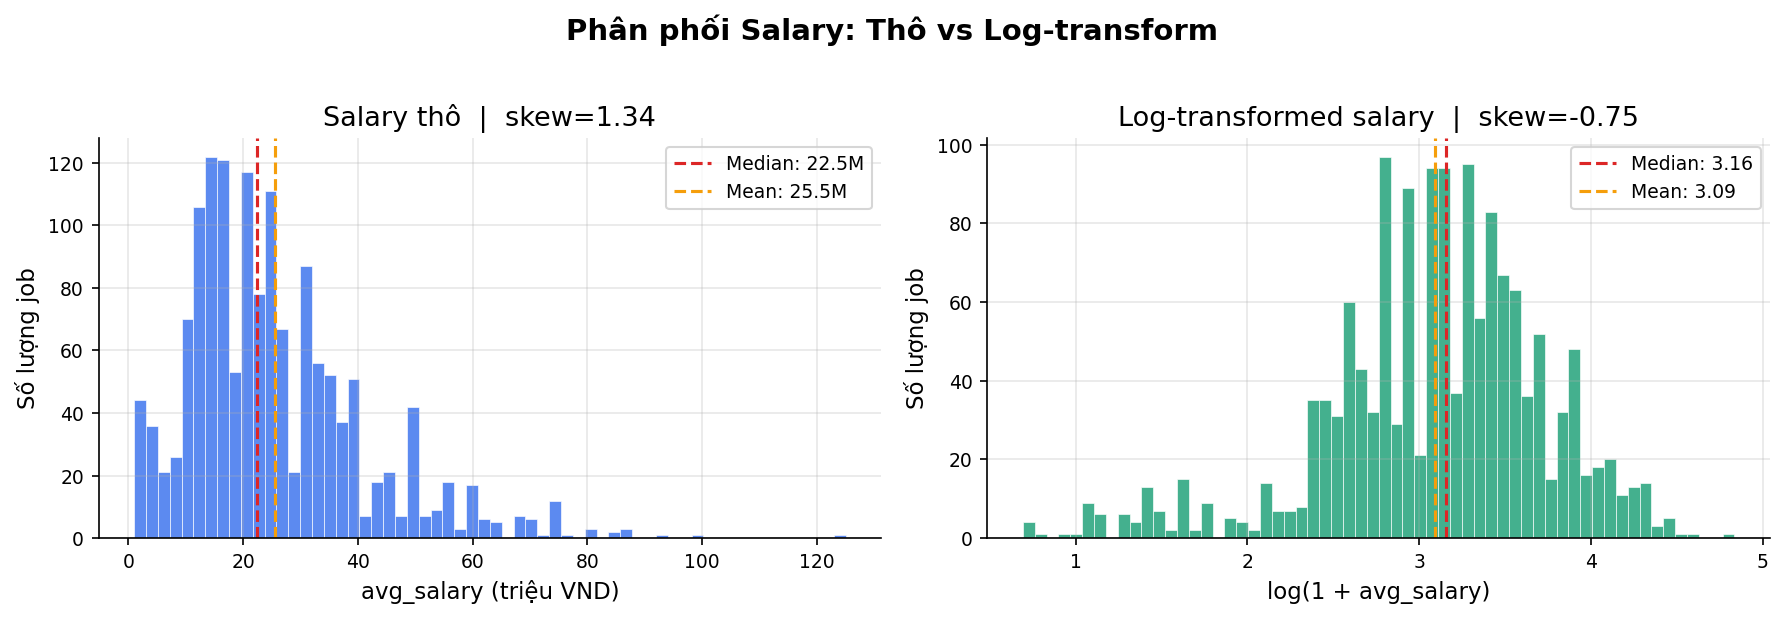

Saved: fig_salary_distribution.png


In [22]:
# --- PLOT: Histogram raw vs log, cạnh nhau ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw salary
ax = axes[0]
ax.hist(df_clean['avg_salary'], bins=60, color='#2563EB', alpha=0.75, edgecolor='white', linewidth=0.4)
ax.axvline(df_clean['avg_salary'].median(), color='#DC2626', linestyle='--', linewidth=1.5,
           label=f"Median: {df_clean['avg_salary'].median():.1f}M")
ax.axvline(df_clean['avg_salary'].mean(), color='#F59E0B', linestyle='--', linewidth=1.5,
           label=f"Mean: {df_clean['avg_salary'].mean():.1f}M")
ax.set_xlabel('avg_salary (triệu VND)')
ax.set_ylabel('Số lượng job')
ax.set_title(f'Salary thô  |  skew={skew_raw:.2f}')
ax.legend(fontsize=9)

# Right: log salary
ax = axes[1]
ax.hist(df_clean['log_avg_salary'], bins=60, color='#059669', alpha=0.75, edgecolor='white', linewidth=0.4)
ax.axvline(df_clean['log_avg_salary'].median(), color='#DC2626', linestyle='--', linewidth=1.5,
           label=f"Median: {df_clean['log_avg_salary'].median():.2f}")
ax.axvline(df_clean['log_avg_salary'].mean(), color='#F59E0B', linestyle='--', linewidth=1.5,
           label=f"Mean: {df_clean['log_avg_salary'].mean():.2f}")
ax.set_xlabel('log(1 + avg_salary)')
ax.set_ylabel('Số lượng job')
ax.set_title(f'Log-transformed salary  |  skew={skew_log:.2f}')
ax.legend(fontsize=9)

fig.suptitle('Phân phối Salary: Thô vs Log-transform', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_salary_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: fig_salary_distribution.png')

Salary thô (trái)
- Phân phối lệch phải rõ ràng với skew = 1.34 — đặc trưng điển hình của dữ liệu lương. Median (22.5M) thấp hơn Mean (25.5M) khoảng 3M, xác nhận có một đuôi dài bên phải do một số vị trí lương rất cao (senior/lead roles, 80–120M+). Phần lớn job tập trung trong khoảng 10–35M, phù hợp với thị trường IT Việt Nam ở mức mid-level.

Log-transformed salary (phải)
- Sau log(1 + x), skew giảm từ 1.34 xuống −0.75 — cải thiện đáng kể nhưng phân phối vẫn chưa hoàn toàn symmetric (lệch nhẹ sang trái). Đáng chú ý là phân phối log có dạng bimodal nhẹ với hai cụm rõ ràng quanh log ≈ 3.0–3.2 và log ≈ 3.6–4.0. Điều này gợi ý có hai nhóm salary segment tiềm ẩn trong data, nhiều khả năng tương ứng với junior/mid và senior/lead.

# Phân phối salary theo 2 nguồn TopCV và ITViec

Raw: 3181 → Valid salary: 1476 → Sau lọc outlier: 1474

Breakdown sau filter:
source
topcv     1296
itviec     178
Name: count, dtype: int64

                          TopCV     ITViec
count                      1296        178
mean                       22.9       44.3
median                     20.0       40.0
std                        13.4       18.4

KS test: stat=0.5830, p=1.5746e-50


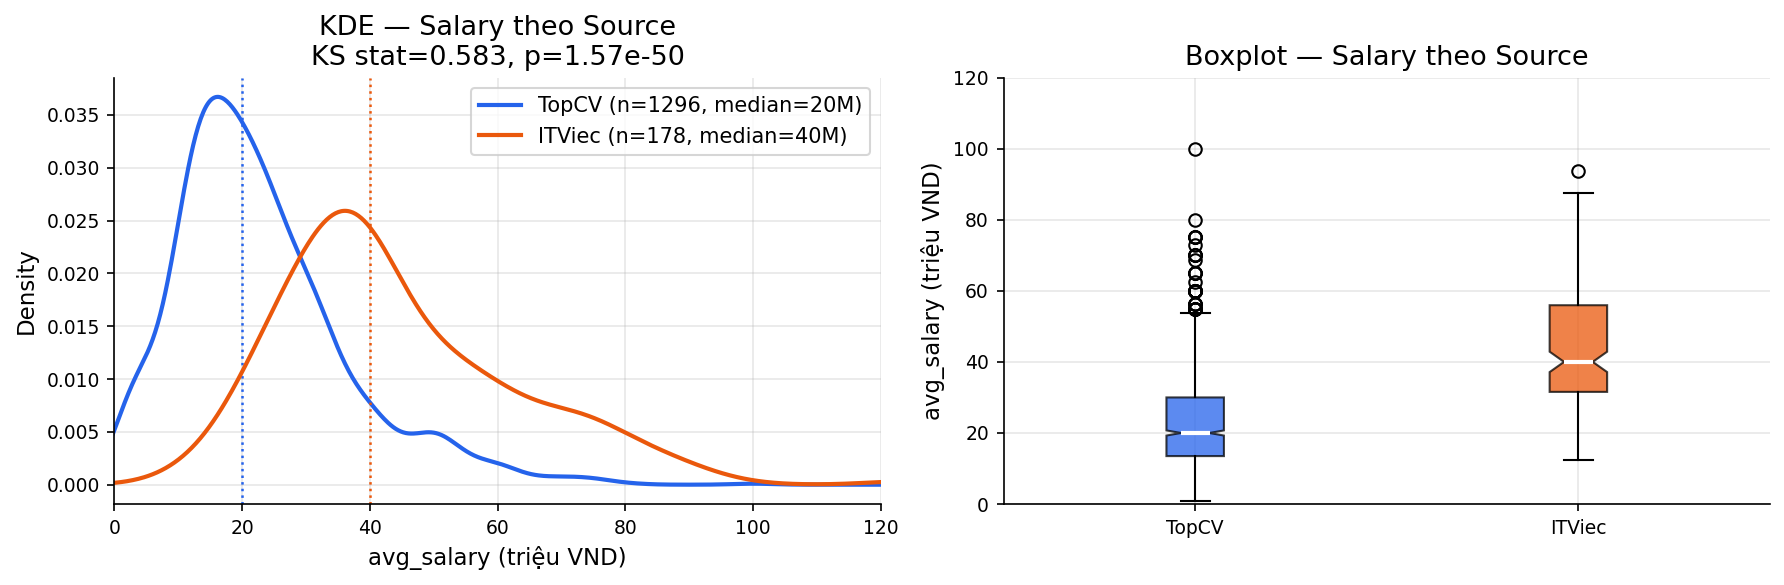

In [29]:
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# --- Filter ĐÚNG: loại missing salary + outlier USD ---
df_valid = df_jobs[~df_jobs['is_missing_salary']].copy()
df_clean = df_valid[df_valid['avg_salary'] <= 200].copy()  # ngưỡng 200M VND

print(f"Raw: {len(df_jobs)} → Valid salary: {len(df_valid)} → Sau lọc outlier: {len(df_clean)}")
print(f"\nBreakdown sau filter:")
print(df_clean['source'].value_counts())

topcv  = df_clean[df_clean['source'] == 'topcv']['avg_salary']
itviec = df_clean[df_clean['source'] == 'itviec']['avg_salary']

ks_stat, ks_p = ks_2samp(topcv, itviec)

print(f"\n{'':20} {'TopCV':>10} {'ITViec':>10}")
print(f"{'count':20} {len(topcv):>10} {len(itviec):>10}")
for stat in ['mean', 'median', 'std']:
    t = getattr(topcv, stat)()
    i = getattr(itviec, stat)()
    print(f"{stat:20} {t:>10.1f} {i:>10.1f}")
print(f"\nKS test: stat={ks_stat:.4f}, p={ks_p:.4e}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for src, data, color in [('TopCV', topcv, '#2563EB'), ('ITViec', itviec, '#EA580C')]:
    data.plot.kde(ax=ax, color=color, linewidth=2,
                  label=f"{src} (n={len(data)}, median={data.median():.0f}M)")
    ax.axvline(data.median(), color=color, linestyle=':', linewidth=1.2)
ax.set_xlim(0, 120)
ax.set_xlabel('avg_salary (triệu VND)')
ax.set_title(f'KDE — Salary theo Source\nKS stat={ks_stat:.3f}, p={ks_p:.2e}')
ax.legend()

ax = axes[1]
bp = ax.boxplot([topcv.values, itviec.values], labels=['TopCV', 'ITViec'],
                patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], ['#2563EB', '#EA580C']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_ylabel('avg_salary (triệu VND)')
ax.set_ylim(0, 120)
ax.set_title('Boxplot — Salary theo Source')

plt.tight_layout()
plt.savefig('fig_source_salary_compare.png', bbox_inches='tight', dpi=150)
plt.show()

**KS test: D=0.580, p≈6×10⁻⁵⁰** → Bác bỏ H₀ với mức tin cậy cực cao: phân phối lương TopCV và ITViec **khác nhau có ý nghĩa thống kê**. KS statistic 0.58 là rất lớn — hai phân phối gần như không chồng lấn.
- KS statistic = 0.583 với p = 1.57e-50 — hai phân phối khác nhau về bản chất, không phải do random variation. Median ITViec (40M) gấp đôi TopCV (20M), và toàn bộ IQR của ITViec gần như nằm trên Q3 của TopCV. Bimodal mà bạn thấy ở log salary trước đó chính là composite của 2 phân phối này stack lên nhau, không phải junior vs senior như tôi đoán ban đầu.

**Phát hiện chính**

| Metric | TopCV | ITViec | Chênh lệch |
|---|---|---|---|
| n (sau filter) | 1,296 | 178 | 7.3× |
| Median (triệu VND) | 20.0 | 40.0 | **2.0×** |
| Mean (triệu VND) | 23.4 | 44.3 | **1.9×** |
| Tỷ lệ missing salary | 47% | **76%** | — |

Shape của KDE cho thấy không phải vài outlier kéo trung bình ITViec lên — **toàn bộ phân phối ITViec dịch sang phải**. TopCV peak ở ~15-20M với long tail, ITViec peak ở ~35-40M.

**Giải thích**

Đây là pattern đã được biết rõ trong thị trường tuyển dụng IT Việt Nam:

- **ITViec định vị premium:** chuyên target mid-to-senior, nhiều job tiếng Anh, công ty product/foreign client, salary range rộng hơn. JD thường viết tiếng Anh và yêu cầu rõ ràng hơn (giải thích vì sao tỷ lệ EN trong text ITViec ~60% theo IAA Methodology của bạn).
- **TopCV broad market:** cover toàn dải từ fresher đến senior, nhiều outsourcing, agency, junior roles, salary thường được "negotiable" hoặc đặt thấp để câu CV.

ITViec vừa có (i) tỷ lệ missing salary cao gấp 1.6× TopCV, vừa có (ii) median lương cao gấp đôi. Pattern này nhất quán với giả thuyết: **ITViec là platform thiên về vị trí senior/cao cấp**, nơi lương thường để "Thoả thuận" và khi công khai thì cao hơn đáng kể. TopCV bao phủ thị trường rộng hơn, bao gồm cả entry-level và mid-level với lương cụ thể.

**Hệ quả methodological cho các bước tiếp theo**

1. **`source` là feature bắt buộc trong mô hình salary prediction** — không thể pool hai dataset, vì sẽ học sai cả về mean lẫn variance.
2. **Stratified train/test split theo `source`** — đảm bảo tỷ lệ TopCV:ITViec trong test set tương đương train set, tránh evaluation bias.
3. **Skill premium analysis (Trục 3) phải control `source`** — dùng partial regression `log(salary) ~ skill + source + level`, không phải median chênh lệch thô. Nếu skill X chỉ xuất hiện ở ITViec, premium thô sẽ bị confounded với platform effect.
4. **Ghi nhận trong Datasheets for Datasets** — đây là một dạng selection bias rõ rệt của bộ dữ liệu, ảnh hưởng đến phạm vi generalization của mô hình.

In [30]:
# ============================================================
#  SECTION 3 — SO SÁNH PHÂN PHỐI LƯƠNG: TopCV vs ITViec
# ============================================================
# Mục tiêu: kiểm tra xem source có phải confounder không.
# Nếu phân phối lương khác nhau đáng kể → cần đưa source vào model
# hoặc phân tích riêng biệt.

topcv_salary  = df_clean[df_clean['source'] == 'topcv']['avg_salary']
itviec_salary = df_clean[df_clean['source'] == 'itviec']['avg_salary']

# Kolmogorov-Smirnov test: H0 = cùng phân phối
ks_stat, ks_p = ks_2samp(topcv_salary, itviec_salary)

print('=== Thống kê mô tả theo source ===')
print(df_clean.groupby('source')['avg_salary'].describe().round(2).to_string())
print()
print(f'KS test: statistic={ks_stat:.4f}, p-value={ks_p:.4f}')

=== Thống kê mô tả theo source ===
         count   mean    std   min    25%   50%    75%    max
source                                                       
itviec   178.0  44.27  18.44  12.5  31.56  40.0  55.94  125.0
topcv   1296.0  22.90  13.44   1.0  13.50  20.0  30.00  100.0

KS test: statistic=0.5830, p-value=0.0000


# Salary x level

Levels found (6): ['Intern', 'Nhân viên', 'Trưởng nhóm', 'Trưởng/Phó phòng', 'Quản lý / Giám sát', 'Senior']


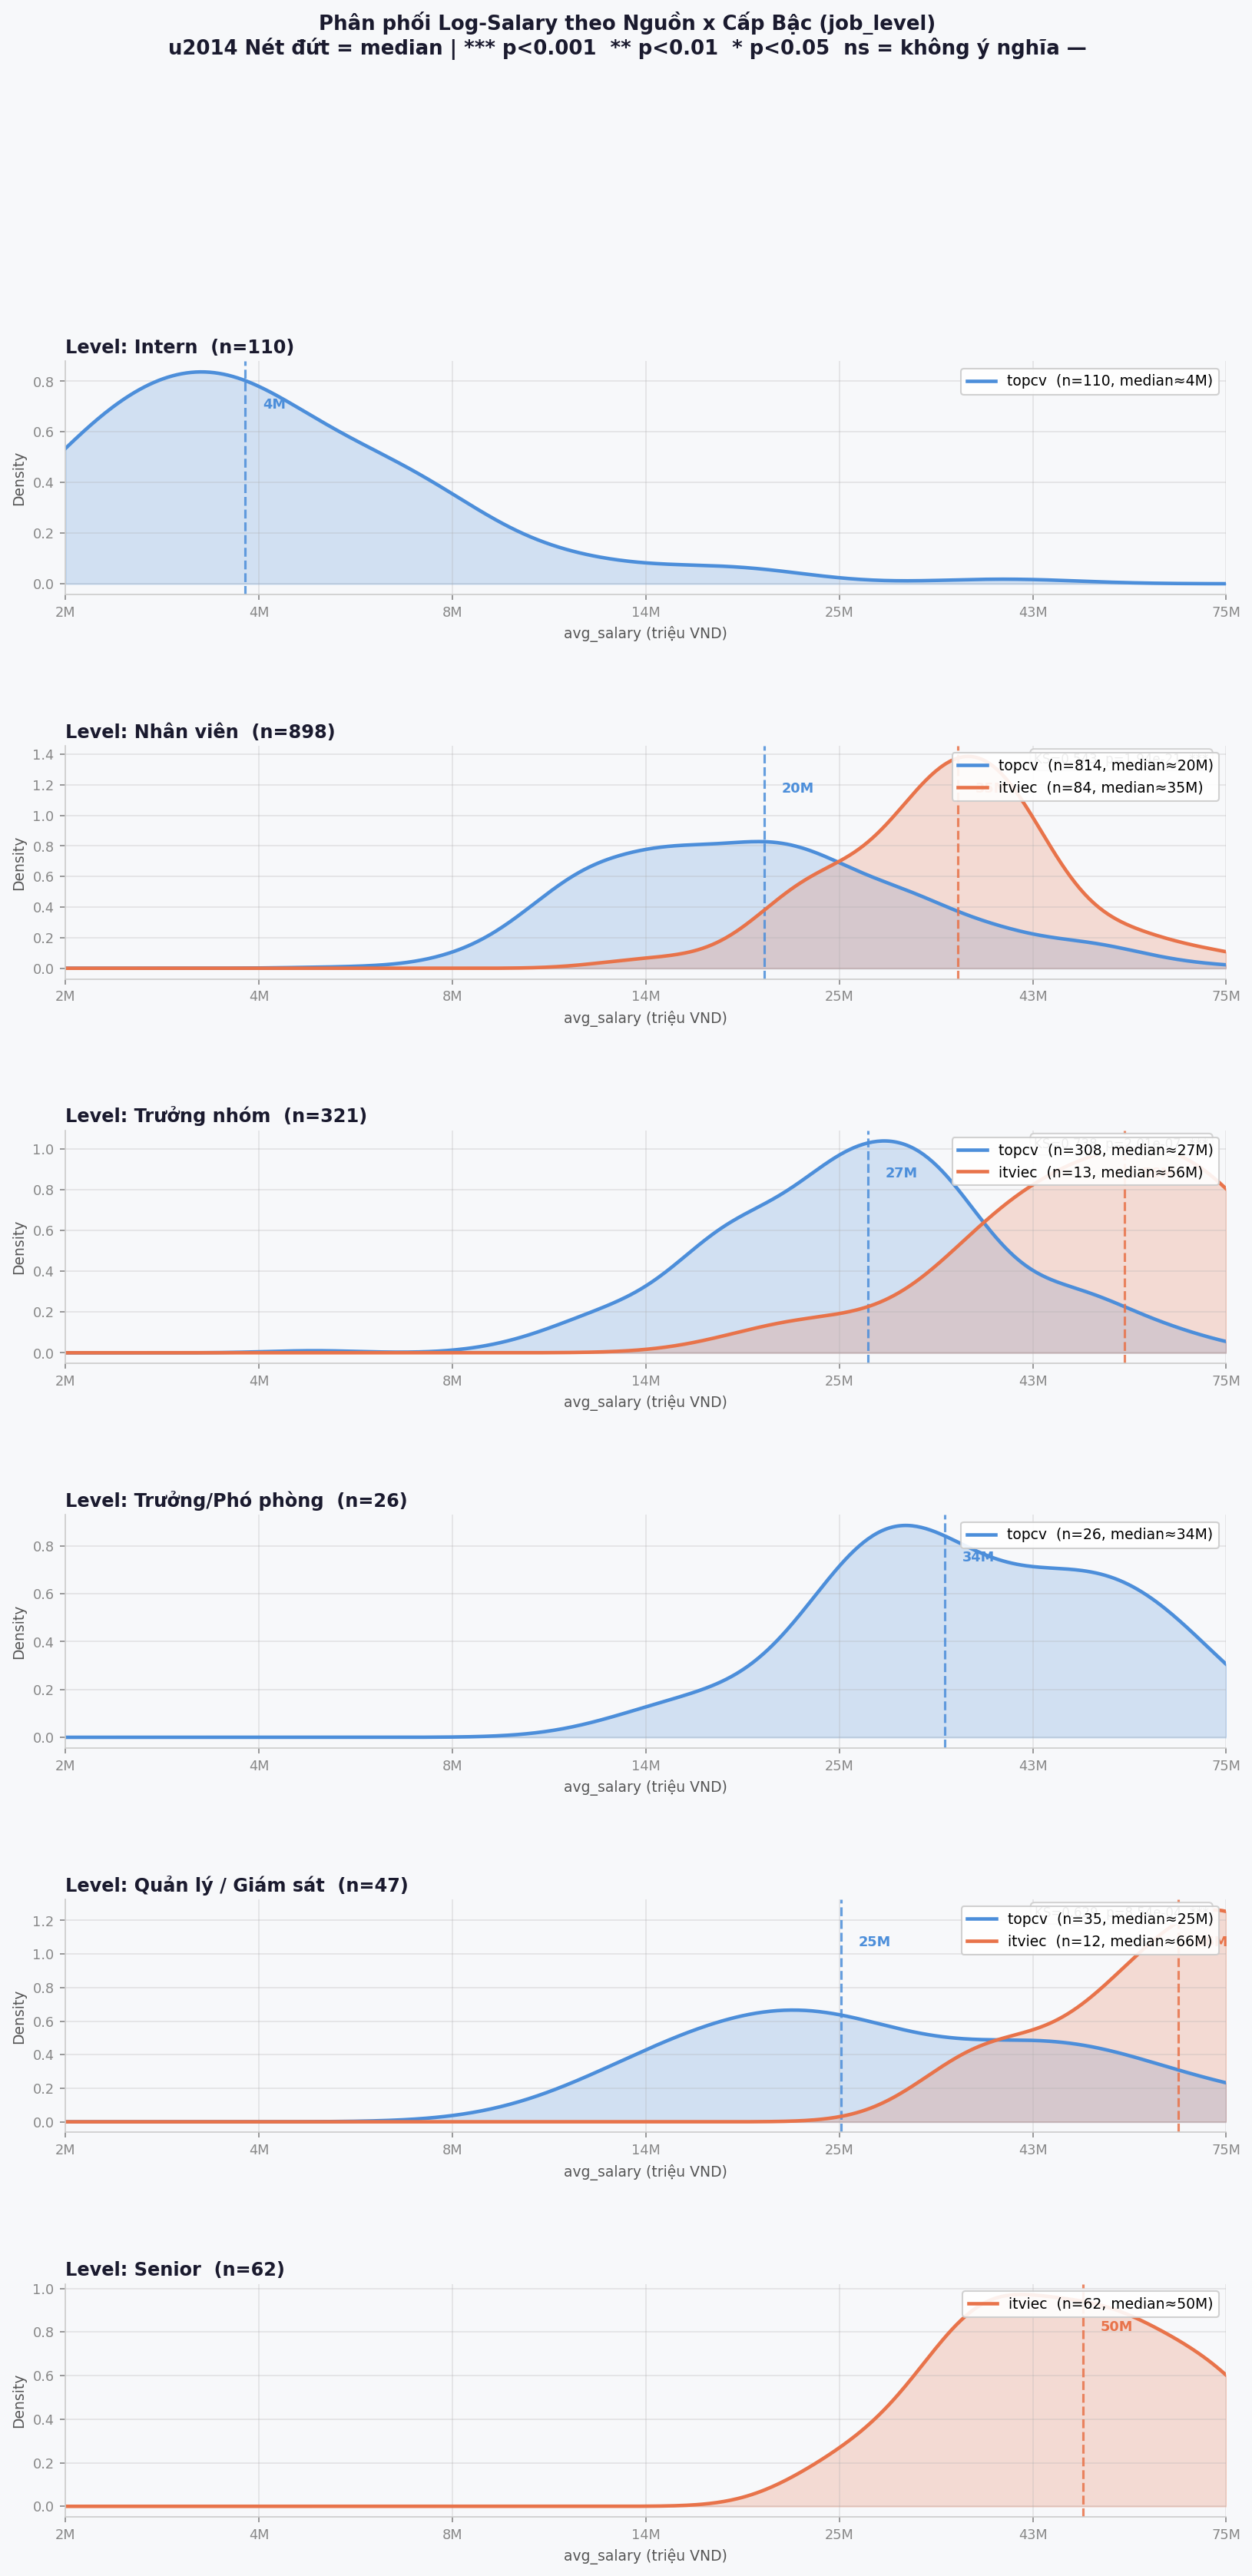

u2713 Saved: salary_kde_source_x_level.png


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── 1. Chuẩn bị ──────────────────────────────────────────────────────────
df_plot = df_clean[["avg_salary", "source", "job_level"]].dropna()
df_plot["log_salary"] = np.log1p(df_plot["avg_salary"])

SOURCE_COLORS = {"topcv": "#4C8EDA", "itviec": "#E8734A"}
sources = ["topcv", "itviec"]

# Tự detect levels, sắp xếp theo median log_salary tăng dần
level_medians = (
    df_plot.groupby("job_level")["log_salary"]
    .median()
    .sort_values()
)
levels_present = level_medians.index.tolist()

# Chỉ giữ level có ít nhất 1 nguồn đủ 10 records
def has_enough_data(level):
    sub = df_plot[df_plot["job_level"] == level]
    return any(len(sub[sub["source"] == s]) >= 10 for s in sources)

levels_present = [l for l in levels_present if has_enough_data(l)]

print(f"Levels found ({len(levels_present)}): {levels_present}")

# ── 2. X-axis range từ data thực ───────────────────────────────────────
log_min = df_plot["log_salary"].quantile(0.01)
log_max = df_plot["log_salary"].quantile(0.99)
x_grid  = np.linspace(log_min, log_max, 500)

# Tick labels: chọn ~7 điểm đều, hiển thị triệu VND
tick_log    = np.linspace(log_min, log_max, 7)
tick_labels = [f"{np.expm1(t):.0f}M" for t in tick_log]

# ── 3. Layout ─────────────────────────────────────────────────────
n_levels = len(levels_present)
fig = plt.figure(figsize=(13, 3.8 * n_levels + 1.5))
fig.patch.set_facecolor("#F7F8FA")

gs = gridspec.GridSpec(n_levels, 1, hspace=0.65)
axes = [fig.add_subplot(gs[i]) for i in range(n_levels)]

# ── 4. Vẽ KDE từng level ─────────────────────────────────────────────────────
for ax, level in zip(axes, levels_present):
    sub = df_plot[df_plot["job_level"] == level]

    ax.set_facecolor("#F7F8FA")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCCCC")

    drawn = []
    peak_densities = []

    for src in sources:
        data = sub[sub["source"] == src]["log_salary"].dropna()
        n = len(data)
        if n < 10:
            continue

        color      = SOURCE_COLORS[src]
        kde        = stats.gaussian_kde(data, bw_method="scott")
        y_vals     = kde(x_grid)
        median_val = np.median(data)

        ax.fill_between(x_grid, y_vals, alpha=0.22, color=color)
        ax.plot(x_grid, y_vals, color=color, linewidth=2.2,
                label=f"{src}  (n={n}, median≈{np.expm1(median_val):.0f}M)")
        ax.axvline(median_val, color=color, linewidth=1.5,
                   linestyle="--", alpha=0.85)

        peak_densities.append(y_vals.max())
        drawn.append(src)

    # Annotate median labels sau khi biết peak density cao nhất
    if peak_densities:
        y_top = max(peak_densities)
        for src in drawn:
            data = sub[sub["source"] == src]["log_salary"].dropna()
            median_val = np.median(data)
            color = SOURCE_COLORS[src]
            ax.text(median_val + (log_max - log_min) * 0.015,
                    y_top * 0.88,
                    f"{np.expm1(median_val):.0f}M",
                    color=color, fontsize=8.5, fontweight="bold", va="top")

    # KS test
    d_top = sub[sub["source"] == "topcv"]["log_salary"].dropna()
    d_itv = sub[sub["source"] == "itviec"]["log_salary"].dropna()
    if len(d_top) >= 10 and len(d_itv) >= 10:
        ks_stat, ks_p = stats.ks_2samp(d_top, d_itv)
        sig = "***" if ks_p < 0.001 else ("**" if ks_p < 0.01 else ("*" if ks_p < 0.05 else "ns"))
        ax.text(0.985, 0.97,
                f"KS={ks_stat:.3f}  p={ks_p:.2e}  {sig}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=8, color="#444",
                bbox=dict(boxstyle="round,pad=0.3", fc="white",
                          ec="#CCCCCC", alpha=0.85))

    # n per level
    n_level = len(sub)
    ax.set_title(f"Level: {level}  (n={n_level})", fontsize=11.5,
                 fontweight="bold", loc="left", pad=5, color="#1A1A2E")
    ax.set_xlabel("avg_salary (triệu VND)", fontsize=9, color="#555")
    ax.set_ylabel("Density", fontsize=9, color="#555")
    ax.set_xlim(log_min, log_max)
    ax.set_xticks(tick_log)
    ax.set_xticklabels(tick_labels, fontsize=8.5)
    ax.tick_params(colors="#888", labelsize=8.5)

    if drawn:
        legend = ax.legend(fontsize=9, framealpha=0.9,
                           loc="upper right", fancybox=True,
                           edgecolor="#CCCCCC")
        legend.get_frame().set_facecolor("white")

# ── 5. Title chung ───────────────────────────────────────────────────
fig.suptitle(
    "Phân phối Log-Salary theo Nguồn x Cấp Bậc (job_level)\n"
    "u2014 Nét đứt = median | *** p<0.001  ** p<0.01  * p<0.05  ns = không ý nghĩa —",
    fontsize=12.5, fontweight="bold", color="#1A1A2E", y=1.005,
)

plt.tight_layout()
plt.savefig("salary_kde_source_x_level.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("u2713 Saved: salary_kde_source_x_level.png")

# Audit

In [32]:
import re
import pandas as pd

# ============================================================
#  AUDIT lại sau khi fix extract_level (title-first + role declaration)
# ============================================================

ROLE_DECLARATION_PATTERNS = [
    r'\bposition\s*[:\-]\s*([^\n.]{1,80})',
    r'\bjob\s*title\s*[:\-]\s*([^\n.]{1,80})',
    r'\brole\s*[:\-]\s*([^\n.]{1,80})',
    r'\bwe\s+(?:are|\'re)\s+(?:looking\s+for|hiring|seeking)\s+(?:an?\s+)?([^\n.]{1,80})',
    r'vị\s*trí\s*[:\-]\s*([^\n.]{1,80})',
    r'chức\s*danh\s*[:\-]\s*([^\n.]{1,80})',
    r'chúng\s*tôi\s+(?:đang\s+)?(?:tìm\s+kiếm|tuyển\s+dụng)\s+(?:một\s+)?([^\n.]{1,80})',
]


def _match_level(text):
    """Return (level, kw, ctx) hoặc (None, None, None)."""
    if not isinstance(text, str) or not text.strip():
        return None, None, None
    t = text.lower()

    groups = [
        ("Quản lý / Giám sát", [
            r'\b(manager|director|chief|cto|ceo|vp)\b',
            r'\bhead of\b',
            r'trưởng phòng|giám đốc',
        ]),
        ("Trưởng nhóm", [
            r'\b(tech|technical|team|group)\s+lead\b',
            r'\blead\b',
            r'trưởng nhóm',
        ]),
        ("Senior", [
            r'\b(senior|expert|principal|staff|architect)\b',
            r'chuyên gia',
        ]),
        ("Junior", [
            r'\b(junior|mid-level|middle)\b',
            r'\bmid\b',
        ]),
        ("Fresher", [
            r'\b(fresher|entry[- ]level)\b',
            r'mới tốt nghiệp',
        ]),
        ("Thực tập sinh", [
            r'\bintern(?:ship|s)?\b',
            r'thực tập sinh',
        ]),
    ]
    for level, pats in groups:
        for pat in pats:
            m = re.search(pat, t)
            if m:
                start = max(0, m.start() - 30)
                end = min(len(t), m.end() + 30)
                return level, m.group(), t[start:end]
    return None, None, None


def extract_level_audit(title, jd='', req=''):
    """
    Return dict: {level, source, kw, ctx, declaration_pat}
      source ∈ {'title', 'jd_declaration', 'default'}
    """
    # Step 1: title
    lvl, kw, ctx = _match_level(title)
    if lvl is not None:
        return {'level': lvl, 'source': 'title', 'kw': kw,
                'ctx': ctx, 'declaration_pat': None}

    # Step 2: explicit role declaration trong JD/req
    combined = (str(jd or '') + ' ' + str(req or '')).lower()
    for pat in ROLE_DECLARATION_PATTERNS:
        for m in re.finditer(pat, combined):
            declared = m.group(1)
            lvl2, kw2, _ = _match_level(declared)
            if lvl2 is not None:
                return {'level': lvl2, 'source': 'jd_declaration',
                        'kw': kw2, 'ctx': f'[{pat[:30]}...] → {declared[:80]}',
                        'declaration_pat': pat[:40]}

    return {'level': 'Nhân viên', 'source': 'default',
            'kw': None, 'ctx': None, 'declaration_pat': None}


# ====== APPLY ======
itviec = df_clean[df_clean['source'] == 'itviec'].copy()
print(f"ITViec records trong df_clean: {len(itviec)}")

audit_results = itviec.apply(
    lambda r: extract_level_audit(r['job_title'],
                                   r.get('job_description', ''),
                                   r.get('requirement', '')),
    axis=1
)

itviec['audit_level'] = audit_results.apply(lambda x: x['level'])
itviec['audit_source'] = audit_results.apply(lambda x: x['source'])
itviec['audit_kw']     = audit_results.apply(lambda x: x['kw'])
itviec['audit_ctx']    = audit_results.apply(lambda x: x['ctx'])

print(f"\nDistribution job_level:")
print(itviec['audit_level'].value_counts())

print(f"\nSource breakdown (signal từ đâu):")
print(itviec['audit_source'].value_counts())

ITViec records trong df_clean: 178

Distribution job_level:
audit_level
Nhân viên             84
Senior                62
Trưởng nhóm           13
Quản lý / Giám sát    12
Junior                 6
Fresher                1
Name: count, dtype: int64

Source breakdown (signal từ đâu):
audit_source
title             91
default           84
jd_declaration     3
Name: count, dtype: int64


In [33]:
# ============================================================
#  AUDIT 1: Per-level inspection
# ============================================================

LEVELS_TO_AUDIT = ['Quản lý / Giám sát', 'Trưởng nhóm', 'Senior',
                   'Junior', 'Fresher', 'Thực tập sinh', 'Nhân viên']
N_SAMPLES = 8

for level in LEVELS_TO_AUDIT:
    sub = itviec[itviec['audit_level'] == level]
    print(f"\n{'='*90}")
    print(f"  LEVEL: {level}  |  n = {len(sub)}")
    print(f"{'='*90}")

    if len(sub) == 0:
        print("  (no records)")
        continue

    # Source breakdown — title vs jd_declaration vs default
    print(f"\n  Source breakdown:")
    src_dist = sub['audit_source'].value_counts()
    for src, n in src_dist.items():
        print(f"    {src:<20}: {n:>4} ({n/len(sub):.1%})")

    # Keyword distribution
    if level != 'Nhân viên':
        kw_dist = sub['audit_kw'].value_counts().head(8)
        print(f"\n  Keyword distribution:")
        for kw, n in kw_dist.items():
            print(f"    {kw!r:<25} → {n:>4} ({n/len(sub):.1%})")

    # Sample
    n_show = min(N_SAMPLES, len(sub))
    sample = sub.sample(n_show, random_state=42)
    print(f"\n  Sample {n_show} records:")

    for idx, row in sample.iterrows():
        print(f"\n  [{idx}] {row['job_title'][:80]}")
        if level == 'Nhân viên':
            print(f"        (default — không có signal)")
        else:
            print(f"        source={row['audit_source']} | kw='{row['audit_kw']}'")
            print(f"        ctx: ...{str(row['audit_ctx'])[:120]}...")


  LEVEL: Quản lý / Giám sát  |  n = 12

  Source breakdown:
    title               :   12 (100.0%)

  Keyword distribution:
    'manager'                 →   12 (100.0%)

  Sample 8 records:

  [3174] VIETTEL SOLUTIONS - Project Manager
        source=title | kw='manager'
        ctx: ...viettel solutions - project manager...

  [3132] Software Project Manager
        source=title | kw='manager'
        ctx: ...software project manager...

  [2639] DevOps Lead/ Manager (Strong AWS)
        source=title | kw='manager'
        ctx: ...devops lead/ manager (strong aws)...

  [3089] Senior Project Manager (English)
        source=title | kw='manager'
        ctx: ...senior project manager (english)...

  [2900] Product Manager
        source=title | kw='manager'
        ctx: ...product manager...

  [2716] (HN) Expert/Manager Software Engineering
        source=title | kw='manager'
        ctx: ...(hn) expert/manager software engineering...

  [2651] Engineering Manager (HRM, SaaS, Golan

In [34]:
# ============================================================
#  AUDIT 2: HIGH-RISK records — signal từ JD declaration
# ============================================================
# Đây là records mà title không có signal, level đến từ fallback.
# Cần verify role declaration thực sự là role này, không phải miscatch.

jd_signal = itviec[itviec['audit_source'] == 'jd_declaration']
print(f"=== {len(jd_signal)} records có level extract từ JD declaration ===\n")

if len(jd_signal) == 0:
    print("(Không có record nào dùng JD fallback — title đủ cover)")
else:
    print("Breakdown theo level:")
    print(jd_signal['audit_level'].value_counts())
    print()

    print("Pattern declaration thường gặp:")
    for idx, row in jd_signal.iterrows():
        print(f"\n  [{idx}] title: {row['job_title']}")
        print(f"        → level: {row['audit_level']} (kw='{row['audit_kw']}')")
        print(f"        ctx: ...{row['audit_ctx']}...")

=== 3 records có level extract từ JD declaration ===

Breakdown theo level:
audit_level
Trưởng nhóm    2
Senior         1
Name: count, dtype: int64

Pattern declaration thường gặp:

  [2492] title: Android HMI SDK Development for Automotive Developer
        → level: Trưởng nhóm (kw='lead')
        ctx: ...[\bwe\s+(?:are|\'re)\s+(?:looki...] → experienced android engineer to lead the development of a common ui library (hmi...

  [2689] title: Fullstack Developer (NodeJS/ReactJS/Java Script)
        → level: Senior (kw='senior')
...     ctx: ...[\bwe\s+(?:are|\'re)\s+(?:looki...] → talented mid/senior fullstack developers who strive to solve the

  [2692] title: Fullstack Developer (Ruby on Rails/ PHP/ AWS/ English)
        → level: Trưởng nhóm (kw='technical lead')
...     ctx: ...[\bposition\s*[:\-]\s*([^\n.]{1...] → senior software engineer/ technical lead


In [35]:
# ============================================================
#  AUDIT 4: Cross-check audit_level vs job_level trong df_clean
# ============================================================
# Verify pipeline đã apply đúng hàm fix

if 'job_level' in itviec.columns:
    mismatch = itviec[itviec['job_level'] != itviec['audit_level']]
    print(f"Tổng ITViec records: {len(itviec)}")
    print(f"Mismatch (job_level dataset vs audit_level): {len(mismatch)}")

    if len(mismatch) > 0:
        print("\n⚠ Có mismatch:")
        print(pd.crosstab(mismatch['job_level'], mismatch['audit_level'], margins=True))

        print("\nMẫu records lệch (top 10):")
        cols = ['job_title', 'job_level', 'audit_level', 'audit_source', 'audit_kw']
        with pd.option_context('display.max_colwidth', 60, 'display.width', 200):
            print(mismatch[cols].head(10).to_string())
    else:
        print("\n✓ 100% khớp — pipeline đã apply hàm fix đầy đủ")

Tổng ITViec records: 178
Mismatch (job_level dataset vs audit_level): 0

✓ 100% khớp — pipeline đã apply hàm fix đầy đủ


# Skill

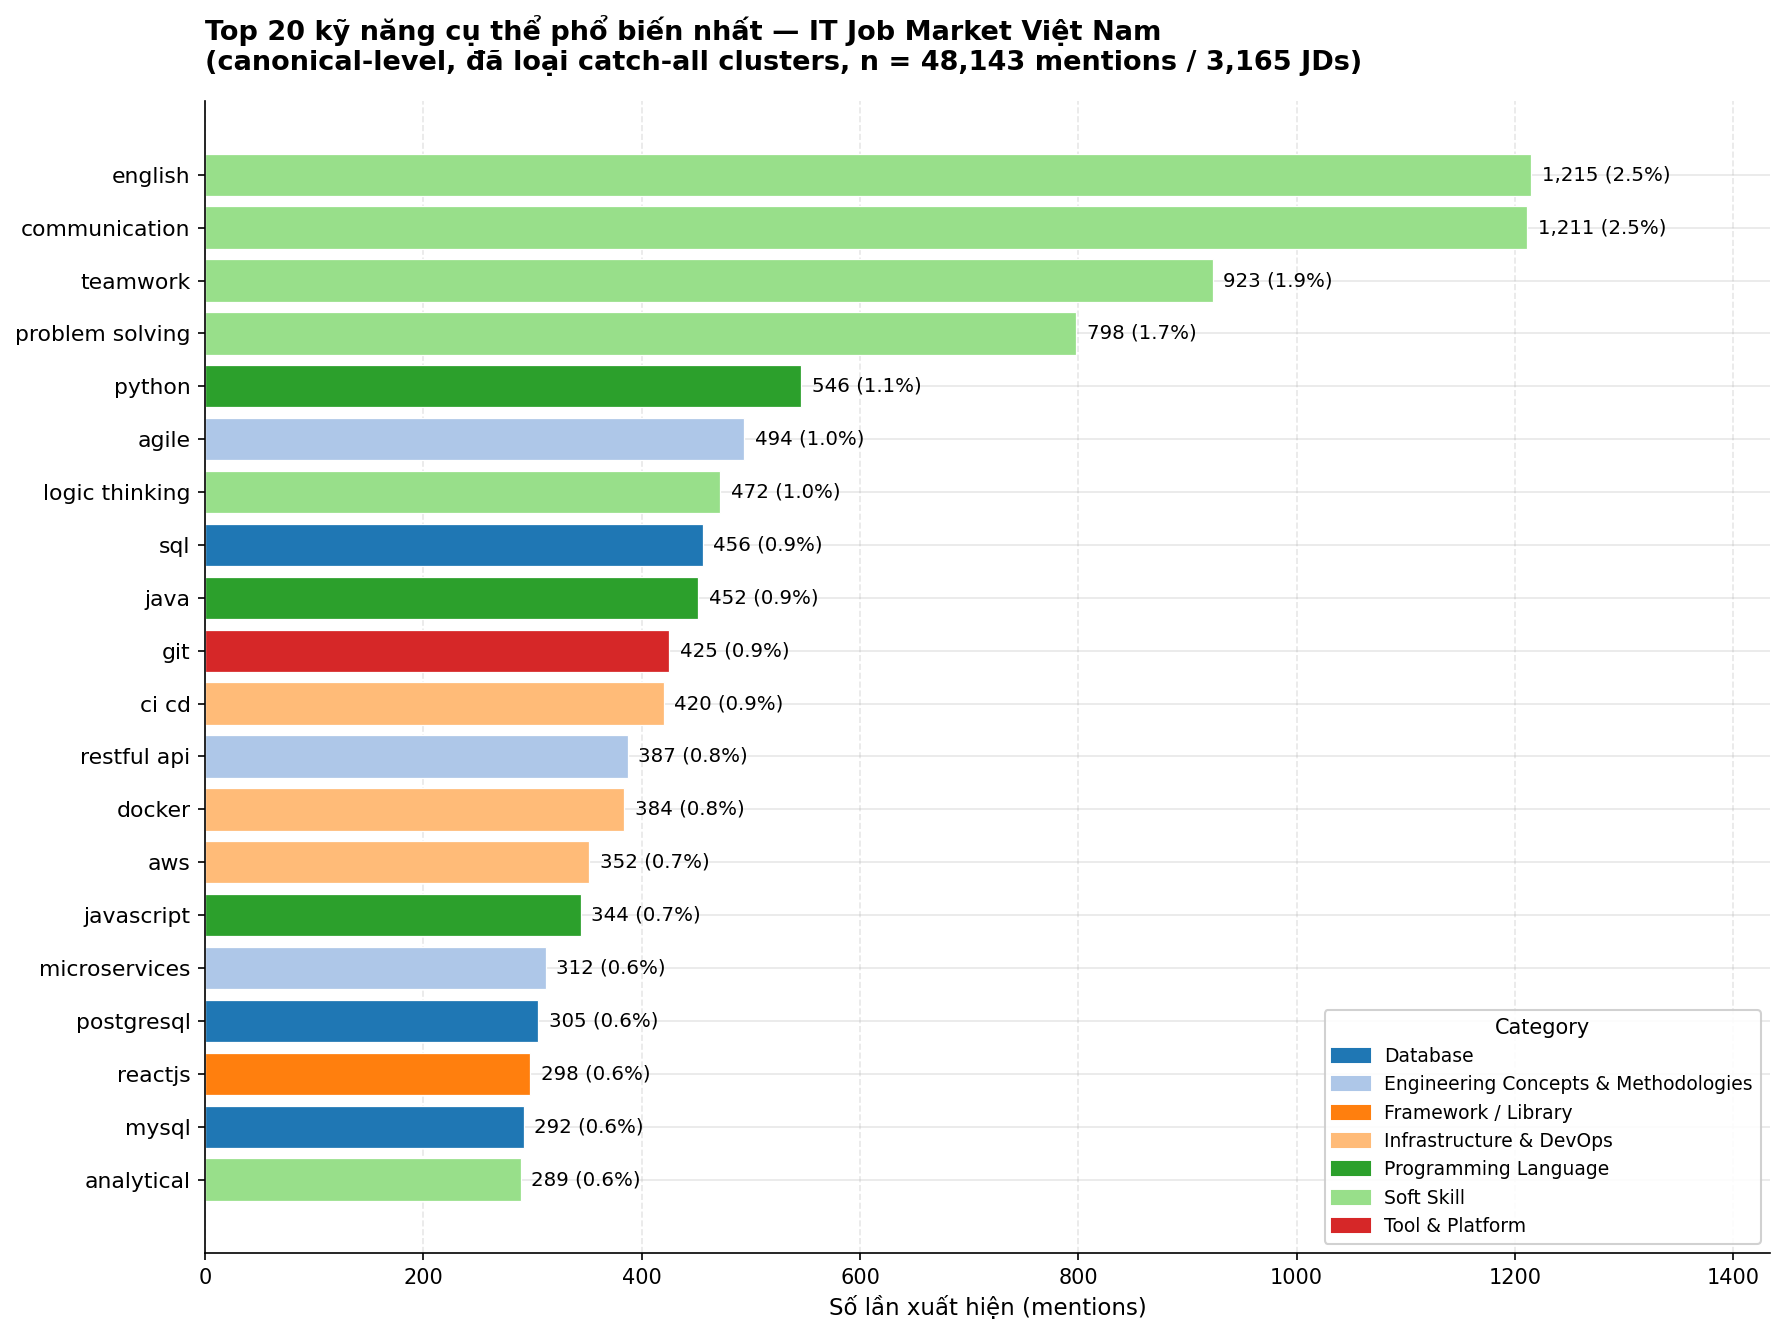

🗑️  Đã loại 8,192 mentions thuộc catch-all clusters
📊 Top 20 chiếm 21.6% tổng mentions (sau lọc)
📊 Category phổ biến nhất trong top 20: {'Soft Skill': 6, 'Database': 3, 'Engineering Concepts & Methodologies': 3}


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============== CONFIG ==============
TOP_N = 20
SKILL_COL = 'final_canonical'

# ============== PREP DATA ==============
df_valid = df_skills.dropna(subset=[SKILL_COL]).copy()

# Bỏ các canonical có chứa "other" — đây là catch-all cluster, không phải skill cụ thể
df_valid = df_valid[~df_valid[SKILL_COL].str.lower().str.contains(r'\bother\b', regex=True, na=False)]

# Top N canonical skills theo frequency
top_skills = (
    df_valid[SKILL_COL]
    .value_counts()
    .head(TOP_N)
    .reset_index()
)
top_skills.columns = [SKILL_COL, 'count']

# Gắn category dominant cho mỗi canonical
dominant_cat = (
    df_valid.groupby(SKILL_COL)['category']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Other')
)
top_skills['category'] = top_skills[SKILL_COL].map(dominant_cat)

# Tỷ lệ trên tổng mentions (sau khi đã lọc)
total_mentions = len(df_valid)
top_skills['pct'] = top_skills['count'] / total_mentions * 100

top_skills = top_skills.sort_values('count', ascending=True).reset_index(drop=True)

# ============== PLOT ==============
fig, ax = plt.subplots(figsize=(12, 9))

categories_sorted = sorted(top_skills['category'].unique())
palette = sns.color_palette('tab20', n_colors=len(categories_sorted))
cat_color = dict(zip(categories_sorted, palette))
colors = top_skills['category'].map(cat_color).values

bars = ax.barh(
    top_skills[SKILL_COL],
    top_skills['count'],
    color=colors,
    edgecolor='white',
    linewidth=0.6
)

x_max = top_skills['count'].max()
for bar, count, pct in zip(bars, top_skills['count'], top_skills['pct']):
    ax.text(
        bar.get_width() + x_max * 0.008,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,} ({pct:.1f}%)',
        va='center', fontsize=9.5
    )

# ============== STYLING ==============
ax.set_xlabel('Số lần xuất hiện (mentions)', fontsize=11)
ax.set_ylabel('')
ax.set_title(
    f'Top {TOP_N} kỹ năng cụ thể phổ biến nhất — IT Job Market Việt Nam\n'
    f'(canonical-level, đã loại catch-all clusters, n = {total_mentions:,} mentions / {df_valid["job_id"].nunique():,} JDs)',
    fontsize=13, fontweight='bold', pad=15, loc='left'
)

legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=cat_color[c], label=c)
    for c in categories_sorted
]
ax.legend(
    handles=legend_elements, title='Category',
    loc='lower right', fontsize=9, title_fontsize=10,
    frameon=True, framealpha=0.9
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_xlim(0, x_max * 1.18)
ax.tick_params(axis='y', labelsize=10.5)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

# ============== SUMMARY ==============
n_removed = len(df_skills.dropna(subset=[SKILL_COL])) - total_mentions
print(f"🗑️  Đã loại {n_removed:,} mentions thuộc catch-all clusters")
print(f"📊 Top {TOP_N} chiếm {top_skills['pct'].sum():.1f}% tổng mentions (sau lọc)")
print(f"📊 Category phổ biến nhất trong top {TOP_N}: "
      f"{top_skills['category'].value_counts().head(3).to_dict()}")

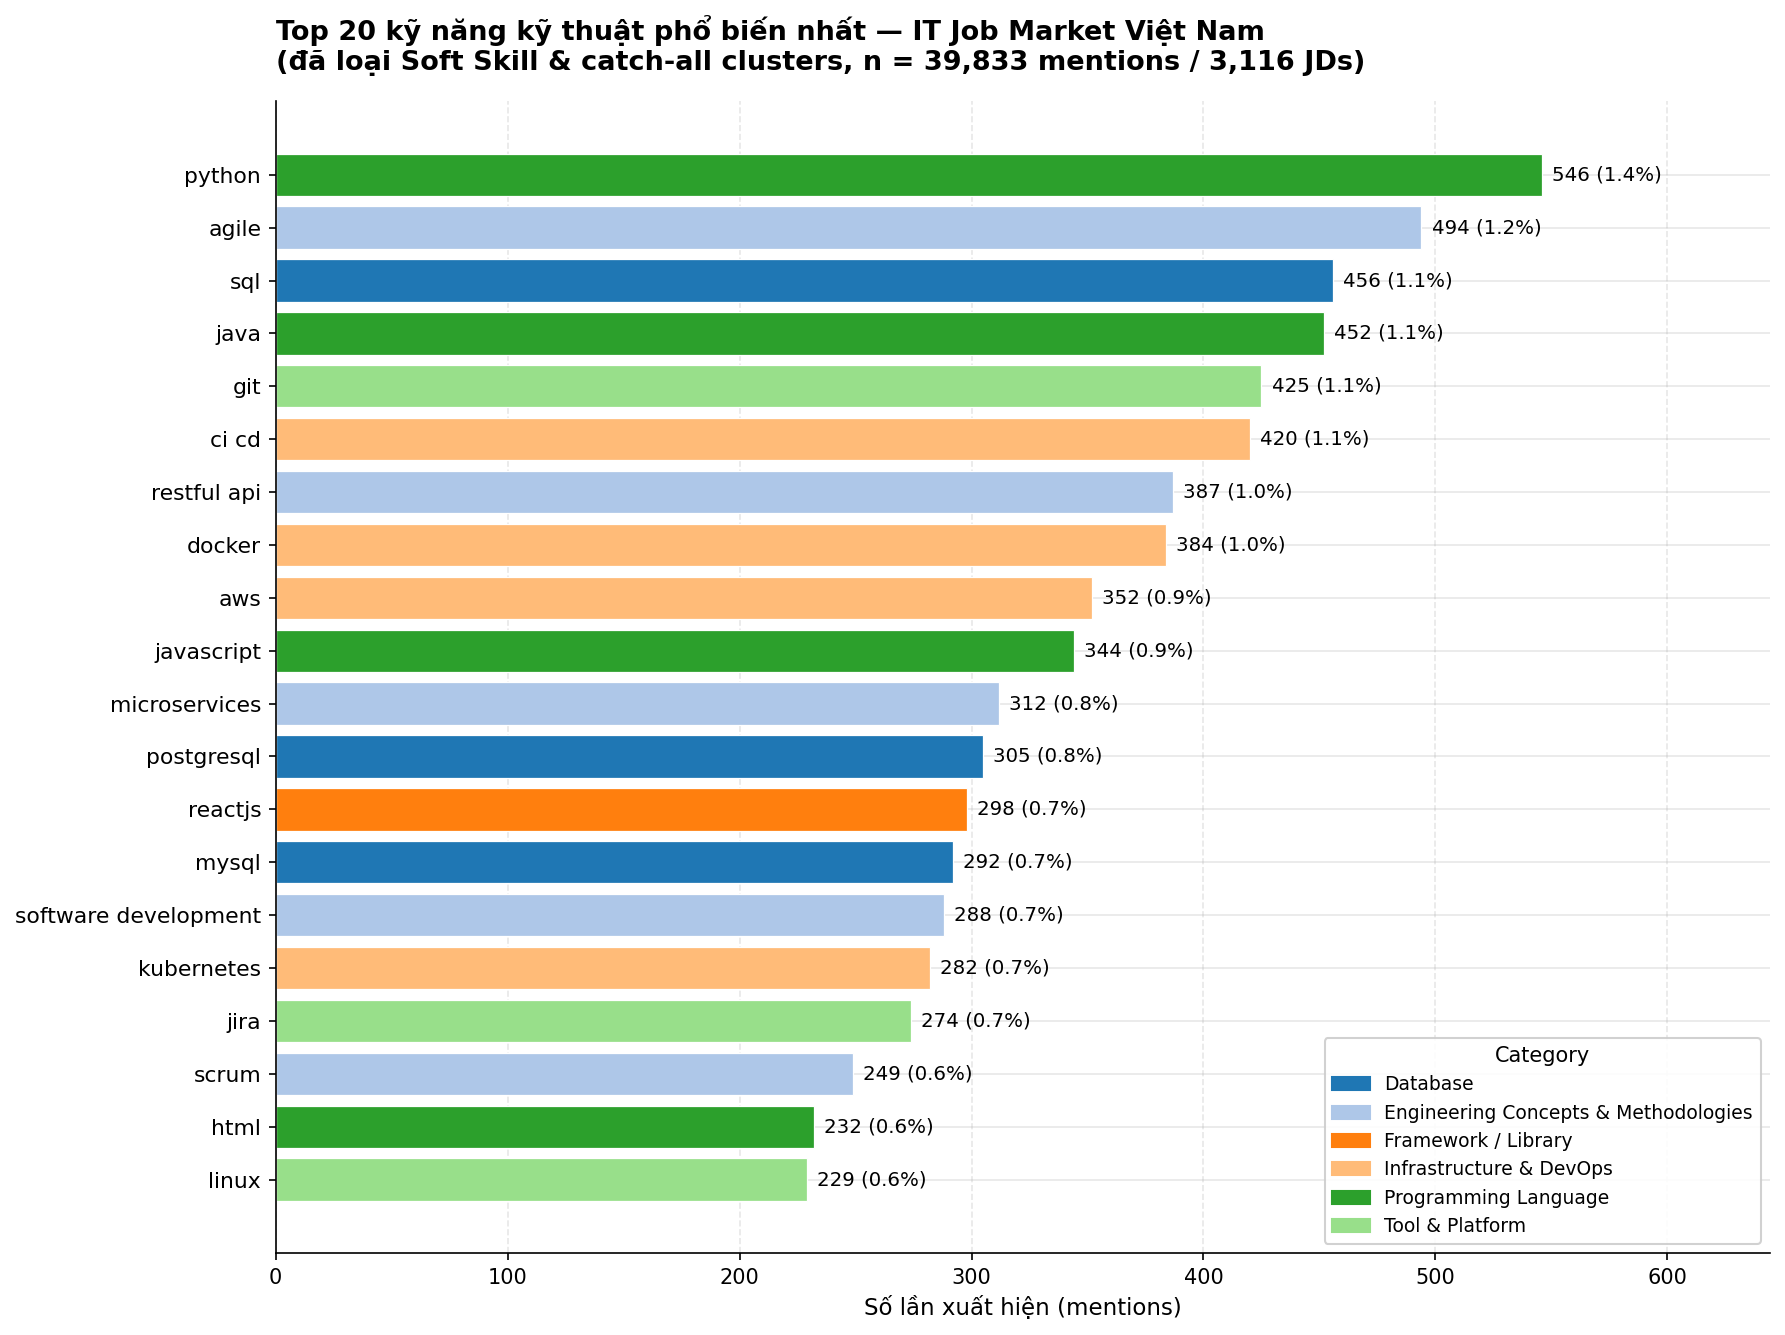

🗑️  Đã loại 8,192 mentions (catch-all) + 8,740 mentions (Soft Skill)
📊 Top 20 chiếm 17.6% tổng technical mentions
📊 Category trong top 20: {'Engineering Concepts & Methodologies': 5, 'Programming Language': 4, 'Infrastructure & DevOps': 4, 'Tool & Platform': 3, 'Database': 3, 'Framework / Library': 1}


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============== CONFIG ==============
TOP_N = 20
SKILL_COL = 'final_canonical'

# ============== PREP DATA ==============
df_valid = df_skills.dropna(subset=[SKILL_COL]).copy()

# Loại catch-all clusters
df_valid = df_valid[~df_valid[SKILL_COL].str.lower().str.contains(r'\bother\b', regex=True, na=False)]

# Loại Soft Skill — focus vào hard/technical skills
df_valid = df_valid[df_valid['category'] != 'Soft Skill']

# Top N
top_skills = (
    df_valid[SKILL_COL]
    .value_counts()
    .head(TOP_N)
    .reset_index()
)
top_skills.columns = [SKILL_COL, 'count']

dominant_cat = (
    df_valid.groupby(SKILL_COL)['category']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Other')
)
top_skills['category'] = top_skills[SKILL_COL].map(dominant_cat)

total_mentions = len(df_valid)
top_skills['pct'] = top_skills['count'] / total_mentions * 100
top_skills = top_skills.sort_values('count', ascending=True).reset_index(drop=True)

# ============== PLOT ==============
fig, ax = plt.subplots(figsize=(12, 9))

categories_sorted = sorted(top_skills['category'].unique())
palette = sns.color_palette('tab20', n_colors=len(categories_sorted))
cat_color = dict(zip(categories_sorted, palette))
colors = top_skills['category'].map(cat_color).values

bars = ax.barh(
    top_skills[SKILL_COL],
    top_skills['count'],
    color=colors,
    edgecolor='white',
    linewidth=0.6
)

x_max = top_skills['count'].max()
for bar, count, pct in zip(bars, top_skills['count'], top_skills['pct']):
    ax.text(
        bar.get_width() + x_max * 0.008,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,} ({pct:.1f}%)',
        va='center', fontsize=9.5
    )

# ============== STYLING ==============
ax.set_xlabel('Số lần xuất hiện (mentions)', fontsize=11)
ax.set_ylabel('')
ax.set_title(
    f'Top {TOP_N} kỹ năng kỹ thuật phổ biến nhất — IT Job Market Việt Nam\n'
    f'(đã loại Soft Skill & catch-all clusters, n = {total_mentions:,} mentions / {df_valid["job_id"].nunique():,} JDs)',
    fontsize=13, fontweight='bold', pad=15, loc='left'
)

legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=cat_color[c], label=c)
    for c in categories_sorted
]
ax.legend(
    handles=legend_elements, title='Category',
    loc='lower right', fontsize=9, title_fontsize=10,
    frameon=True, framealpha=0.9
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_xlim(0, x_max * 1.18)
ax.tick_params(axis='y', labelsize=10.5)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

# ============== SUMMARY ==============
total_raw = len(df_skills.dropna(subset=[SKILL_COL]))
n_other   = total_raw - len(df_skills.dropna(subset=[SKILL_COL])[
    ~df_skills.dropna(subset=[SKILL_COL])[SKILL_COL].str.lower().str.contains(r'\bother\b', regex=True, na=False)
])
n_soft    = len(df_skills[df_skills['category'] == 'Soft Skill'])
print(f"🗑️  Đã loại {n_other:,} mentions (catch-all) + {n_soft:,} mentions (Soft Skill)")
print(f"📊 Top {TOP_N} chiếm {top_skills['pct'].sum():.1f}% tổng technical mentions")
print(f"📊 Category trong top {TOP_N}: {top_skills['category'].value_counts().to_dict()}")

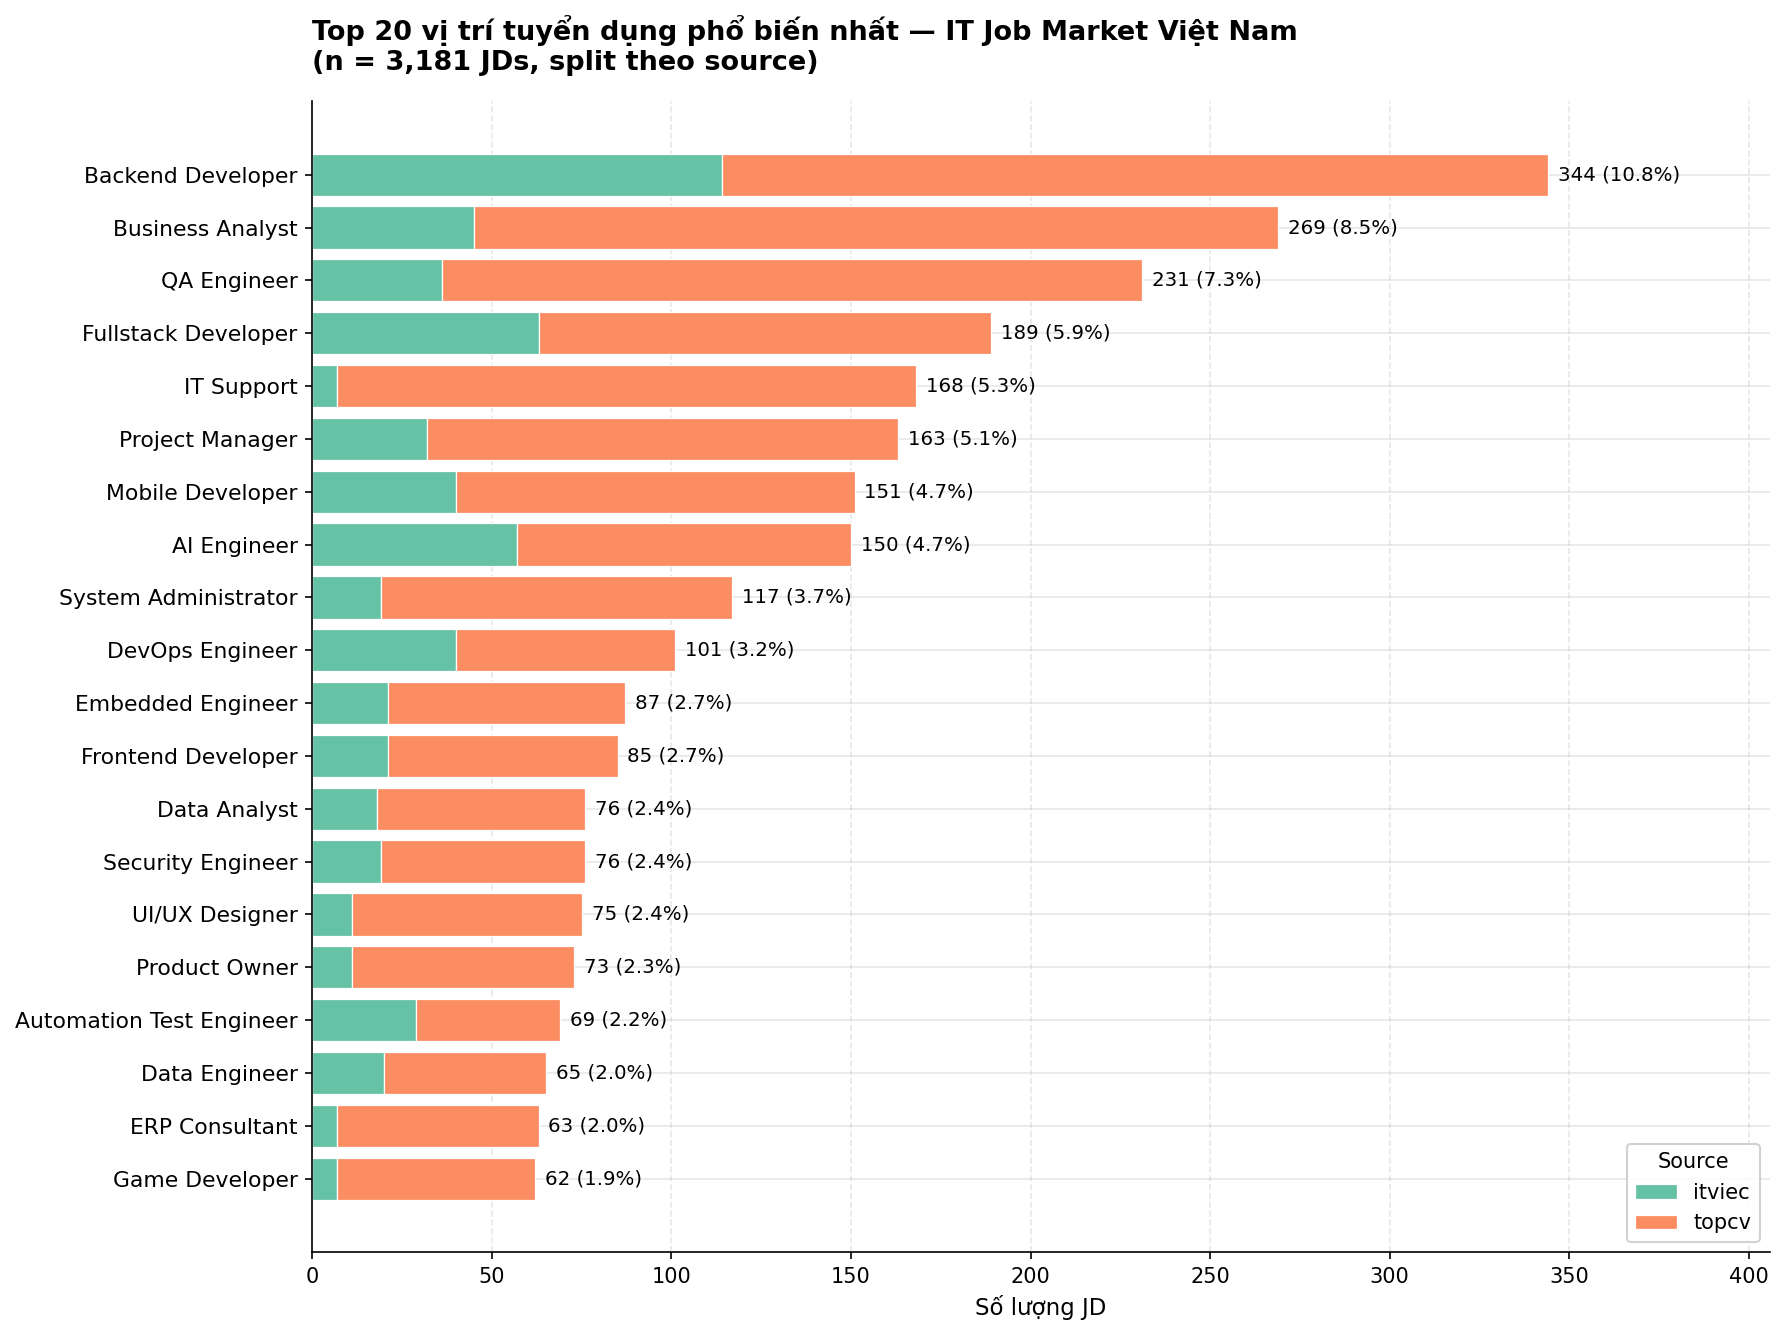

📊 Top 20 chiếm 82.2% tổng JDs

source                    itviec  topcv  total
standardized_title                            
Backend Developer            114    230    344
Business Analyst              45    224    269
QA Engineer                   36    195    231
Fullstack Developer           63    126    189
IT Support                     7    161    168
Project Manager               32    131    163
Mobile Developer              40    111    151
AI Engineer                   57     93    150
System Administrator          19     98    117
DevOps Engineer               40     61    101
Embedded Engineer             21     66     87
Frontend Developer            21     64     85
Data Analyst                  18     58     76
Security Engineer             19     57     76
UI/UX Designer                11     64     75
Product Owner                 11     62     73
Automation Test Engineer      29     40     69
Data Engineer                 20     45     65
ERP Consultant               

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============== CONFIG ==============
TOP_N = 20
DF = df_jobs
TITLE_COL = 'standardized_title'
SOURCE_COL = 'source'   # đổi nếu tên cột khác

# ============== PREP DATA ==============
df_t = DF.dropna(subset=[TITLE_COL]).copy()

# Count theo từng (title, source)
pivot = (
    df_t.groupby([TITLE_COL, SOURCE_COL])
    .size()
    .unstack(fill_value=0)   # cột = từng source
)

# Thêm total để sort, lấy top N
# Thêm total để sort, lấy top N
pivot['_total'] = pivot.sum(axis=1)
pivot = pivot.nlargest(TOP_N, '_total').drop(columns='_total')

# Sort ascending theo tổng 2 source — bar lớn nhất hiện ở trên cùng
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

total_jobs = len(df_t)
sources = pivot.columns.tolist()

# ============== PLOT ==============
fig, ax = plt.subplots(figsize=(12, 9))

src_palette = sns.color_palette('Set2', n_colors=len(sources))
src_color = dict(zip(sources, src_palette))

# Vẽ stacked bar từng source
lefts = pd.Series([0] * len(pivot), index=pivot.index)
bar_containers = {}
for src in sources:
    bars = ax.barh(
        pivot.index,
        pivot[src],
        left=lefts,
        color=src_color[src],
        edgecolor='white',
        linewidth=0.6,
        label=src
    )
    bar_containers[src] = bars
    lefts = lefts + pivot[src]

# Annotate total count ở cuối bar
totals = pivot.sum(axis=1)
x_max = totals.max()
for title, total in totals.items():
    pct = total / total_jobs * 100
    ax.text(
        total + x_max * 0.008,
        pivot.index.get_loc(title),
        f'{total:,} ({pct:.1f}%)',
        va='center', fontsize=9.5
    )

# ============== STYLING ==============
ax.set_xlabel('Số lượng JD', fontsize=11)
ax.set_ylabel('')
ax.set_title(
    f'Top {TOP_N} vị trí tuyển dụng phổ biến nhất — IT Job Market Việt Nam\n'
    f'(n = {total_jobs:,} JDs, split theo source)',
    fontsize=13, fontweight='bold', pad=15, loc='left'
)

ax.legend(title='Source', loc='lower right',
          fontsize=10, title_fontsize=10, frameon=True, framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_xlim(0, x_max * 1.18)
ax.tick_params(axis='y', labelsize=10.5)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

# ============== SUMMARY ==============
print(f"📊 Top {TOP_N} chiếm {totals.sum() / total_jobs * 100:.1f}% tổng JDs")
print(f"\n{pivot.assign(total=totals).sort_values('total', ascending=False).to_string()}")

In [72]:
# ============== CLEAN SALARY ==============
df_jobs_sal = df_jobs[df_jobs[SALARY_COL] > 0].copy()   # loại "salary ẩn"

# Loại outlier bằng IQR (3× IQR upper fence)
Q1  = df_jobs_sal[SALARY_COL].quantile(0.25)
Q3  = df_jobs_sal[SALARY_COL].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR

df_jobs_sal = df_jobs_sal[df_jobs_sal[SALARY_COL] <= upper_fence]

print(f"✅ Jobs có salary hợp lệ: {len(df_jobs_sal):,} / {len(df_jobs):,} "
      f"({len(df_jobs_sal)/len(df_jobs)*100:.1f}%)")
print(f"📊 Salary range sau clean: {df_jobs_sal[SALARY_COL].min():.1f}M – "
      f"{df_jobs_sal[SALARY_COL].max():.1f}M triệu VNĐ")
print(f"📊 Median salary: {df_jobs_sal[SALARY_COL].median():.1f}M")
print(f"   Upper fence dùng để loại outlier: {upper_fence:.1f}M")

✅ Jobs có salary hợp lệ: 1,468 / 3,181 (46.1%)
📊 Salary range sau clean: 1.0M – 83.8M triệu VNĐ
📊 Median salary: 22.5M
   Upper fence dùng để loại outlier: 85.0M


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============== CONFIG ==============
SALARY_COL = 'avg_salary'   # đổi theo tên cột thực tế
                             # nếu có min/max thì tính: df_jobs['avg_salary'] = (df_jobs['min_salary'] + df_jobs['max_salary']) / 2
SKILL_COL  = 'final_canonical'
MIN_JOBS   = 10              # chỉ skill có đủ sample mới tin được
TOP_N      = 15
UNIT = 1   # salary đã là triệu VNĐ

# Merge dùng df_jobs_sal thay vì df_jobs
df_sal = (
    df_skills
    .merge(df_jobs_sal[['job_id', SALARY_COL]], on='job_id', how='inner')  # inner: chỉ giữ jobs có salary hợp lệ
    .dropna(subset=[SALARY_COL, SKILL_COL])
)
df_sal = df_sal[~df_sal[SKILL_COL].str.lower().str.contains(r'\bother\b', regex=True, na=False)]
df_sal = df_sal[df_sal['category'] != 'Soft Skill']

# ============== AGG PER SKILL ==============
skill_salary = (
    df_sal.drop_duplicates(subset=['job_id', SKILL_COL])
    .groupby(SKILL_COL)
    .agg(
        avg_salary   = (SALARY_COL, 'mean'),
        median_salary= (SALARY_COL, 'median'),
        std_salary   = (SALARY_COL, 'std'),
        n_jobs       = ('job_id', 'nunique'),
        category     = ('category', lambda x: x.mode().iloc[0])
    )
    .reset_index()
    .query(f'n_jobs >= {MIN_JOBS}')   # filter min sample
)

# Category color map
all_cats  = sorted(skill_salary['category'].unique())
palette   = sns.color_palette('tab20', n_colors=len(all_cats))
cat_color = dict(zip(all_cats, palette))

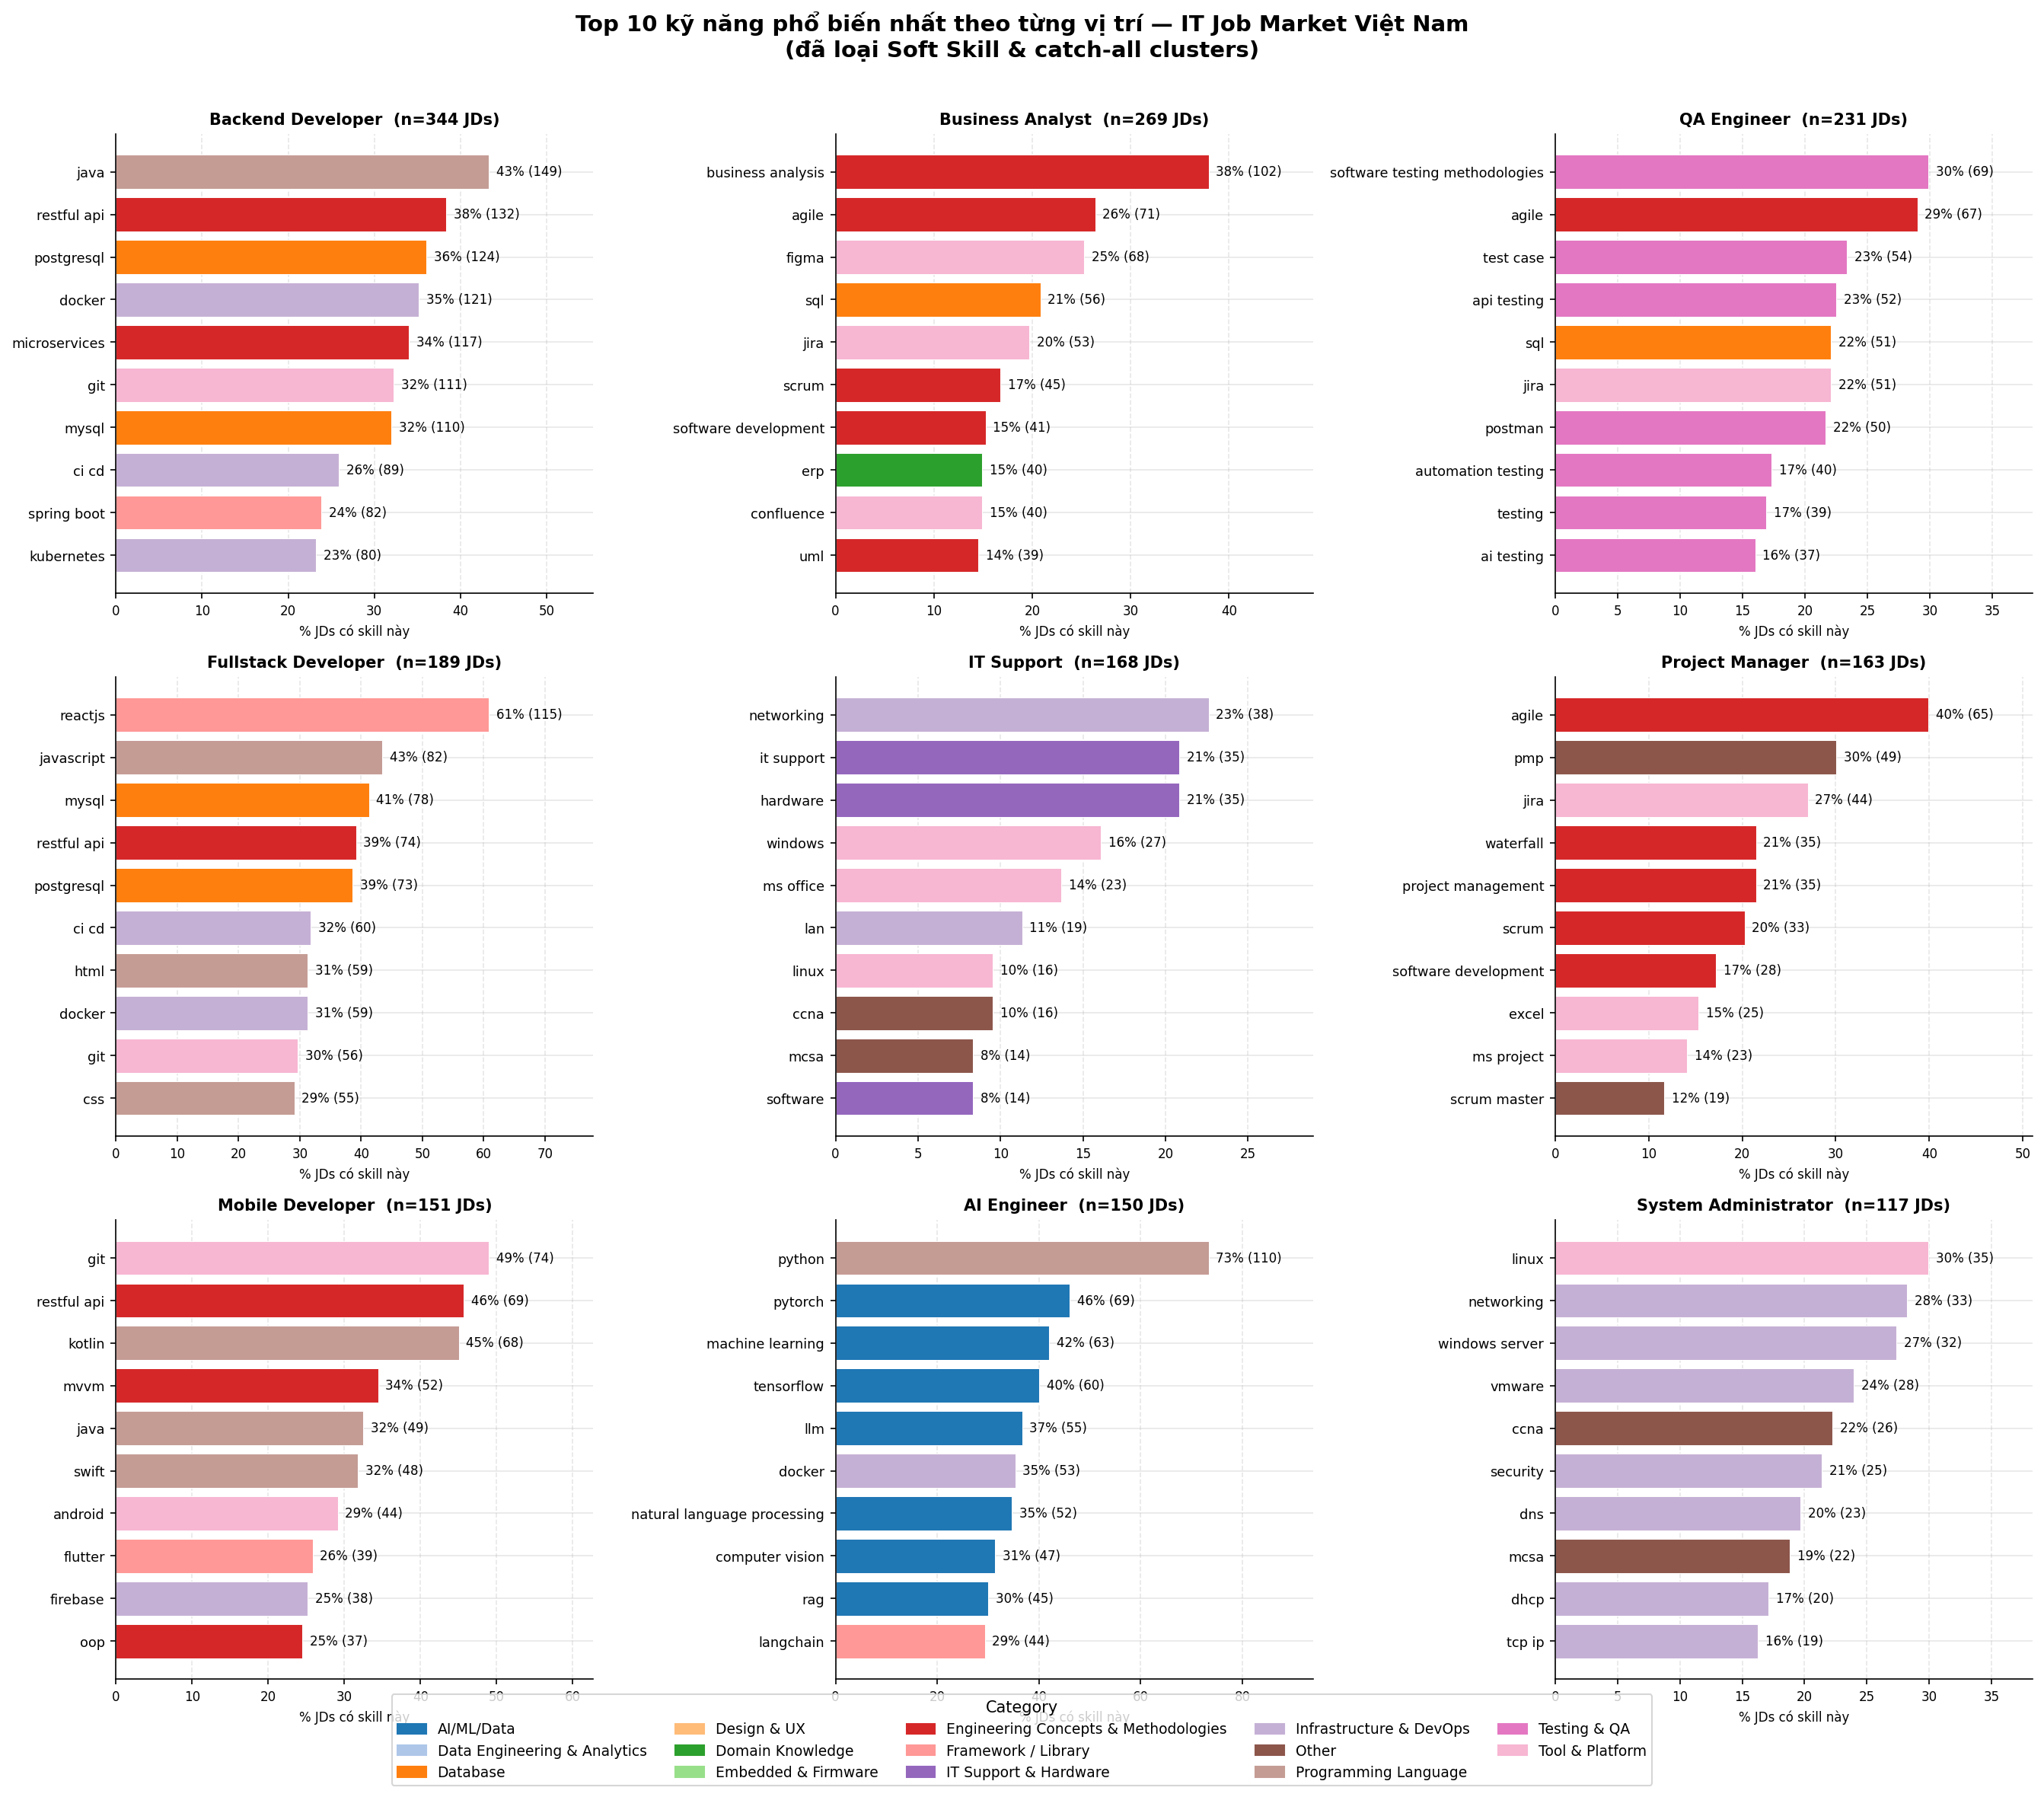

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# ============== CONFIG ==============
TOP_JOBS          = 9    # nên chọn số chia hết cho NCOLS để grid đều
TOP_SKILLS_PER_JOB = 10
NCOLS             = 3
SKILL_COL         = 'final_canonical'
TITLE_COL         = 'standardized_title'

# ============== MERGE & FILTER ==============
df_merged = df_skills.merge(
    df_jobs[['job_id', TITLE_COL]], on='job_id', how='left'
)
df_merged = df_merged[
    ~df_merged[SKILL_COL].str.lower().str.contains(r'\bother\b', regex=True, na=False)
]
df_merged = df_merged[df_merged['category'] != 'Soft Skill']
df_merged = df_merged.dropna(subset=[SKILL_COL, TITLE_COL])

# Top jobs
top_job_list = (
    df_jobs.dropna(subset=[TITLE_COL])[TITLE_COL]
    .value_counts()
    .head(TOP_JOBS)
    .index.tolist()
)

# Category color map — dùng nhất quán với các chart trước
all_cats = sorted(df_merged['category'].dropna().unique())
palette  = sns.color_palette('tab20', n_colors=len(all_cats))
cat_color = dict(zip(all_cats, palette))

# ============== FACETED PLOT ==============
nrows = math.ceil(TOP_JOBS / NCOLS)
fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 6, nrows * 5))
axes = axes.flatten()

for i, job_title in enumerate(top_job_list):
    ax = axes[i]

    # Skills của riêng job này
    df_job = df_merged[df_merged[TITLE_COL] == job_title]

    # Đếm số JD unique có mỗi skill (tránh double-count)
    top_skills = (
        df_job.drop_duplicates(subset=['job_id', SKILL_COL])
        .groupby(SKILL_COL)['job_id']
        .nunique()
        .nlargest(TOP_SKILLS_PER_JOB)
        .reset_index(name='n_jobs')
    )

    # % prevalence trong job này
    total_this_job = df_jobs[df_jobs[TITLE_COL] == job_title]['job_id'].nunique()
    top_skills['pct'] = top_skills['n_jobs'] / total_this_job * 100

    # Gắn category dominant
    dom_cat = df_job.groupby(SKILL_COL)['category'].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else 'Other'
    )
    top_skills['category'] = top_skills[SKILL_COL].map(dom_cat).fillna('Other')
    top_skills = top_skills.sort_values('pct', ascending=True)

    colors = top_skills['category'].map(cat_color).fillna('gray').values

    bars = ax.barh(
        top_skills[SKILL_COL], top_skills['pct'],
        color=colors, edgecolor='white', linewidth=0.5
    )

    # Annotate: % + count tuyệt đối
    x_max = top_skills['pct'].max()
    for bar, pct, n in zip(bars, top_skills['pct'], top_skills['n_jobs']):
        ax.text(
            bar.get_width() + x_max * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.0f}% ({n})',
            va='center', fontsize=8
        )

    ax.set_title(f'{job_title}  (n={total_this_job:,} JDs)',
                 fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('% JDs có skill này', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_xlim(0, x_max * 1.28)
    ax.tick_params(axis='y', labelsize=8.5)
    ax.tick_params(axis='x', labelsize=8)

# Ẩn subplot thừa nếu TOP_JOBS không chia hết NCOLS
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# ============== SHARED LEGEND ==============
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=cat_color[c], label=c)
    for c in all_cats
]
fig.legend(
    handles=legend_elements, title='Category',
    loc='lower center', ncol=5, fontsize=9, title_fontsize=10,
    bbox_to_anchor=(0.5, -0.03), frameon=True
)

fig.suptitle(
    f'Top {TOP_SKILLS_PER_JOB} kỹ năng phổ biến nhất theo từng vị trí — IT Job Market Việt Nam\n'
    f'(đã loại Soft Skill & catch-all clusters)',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

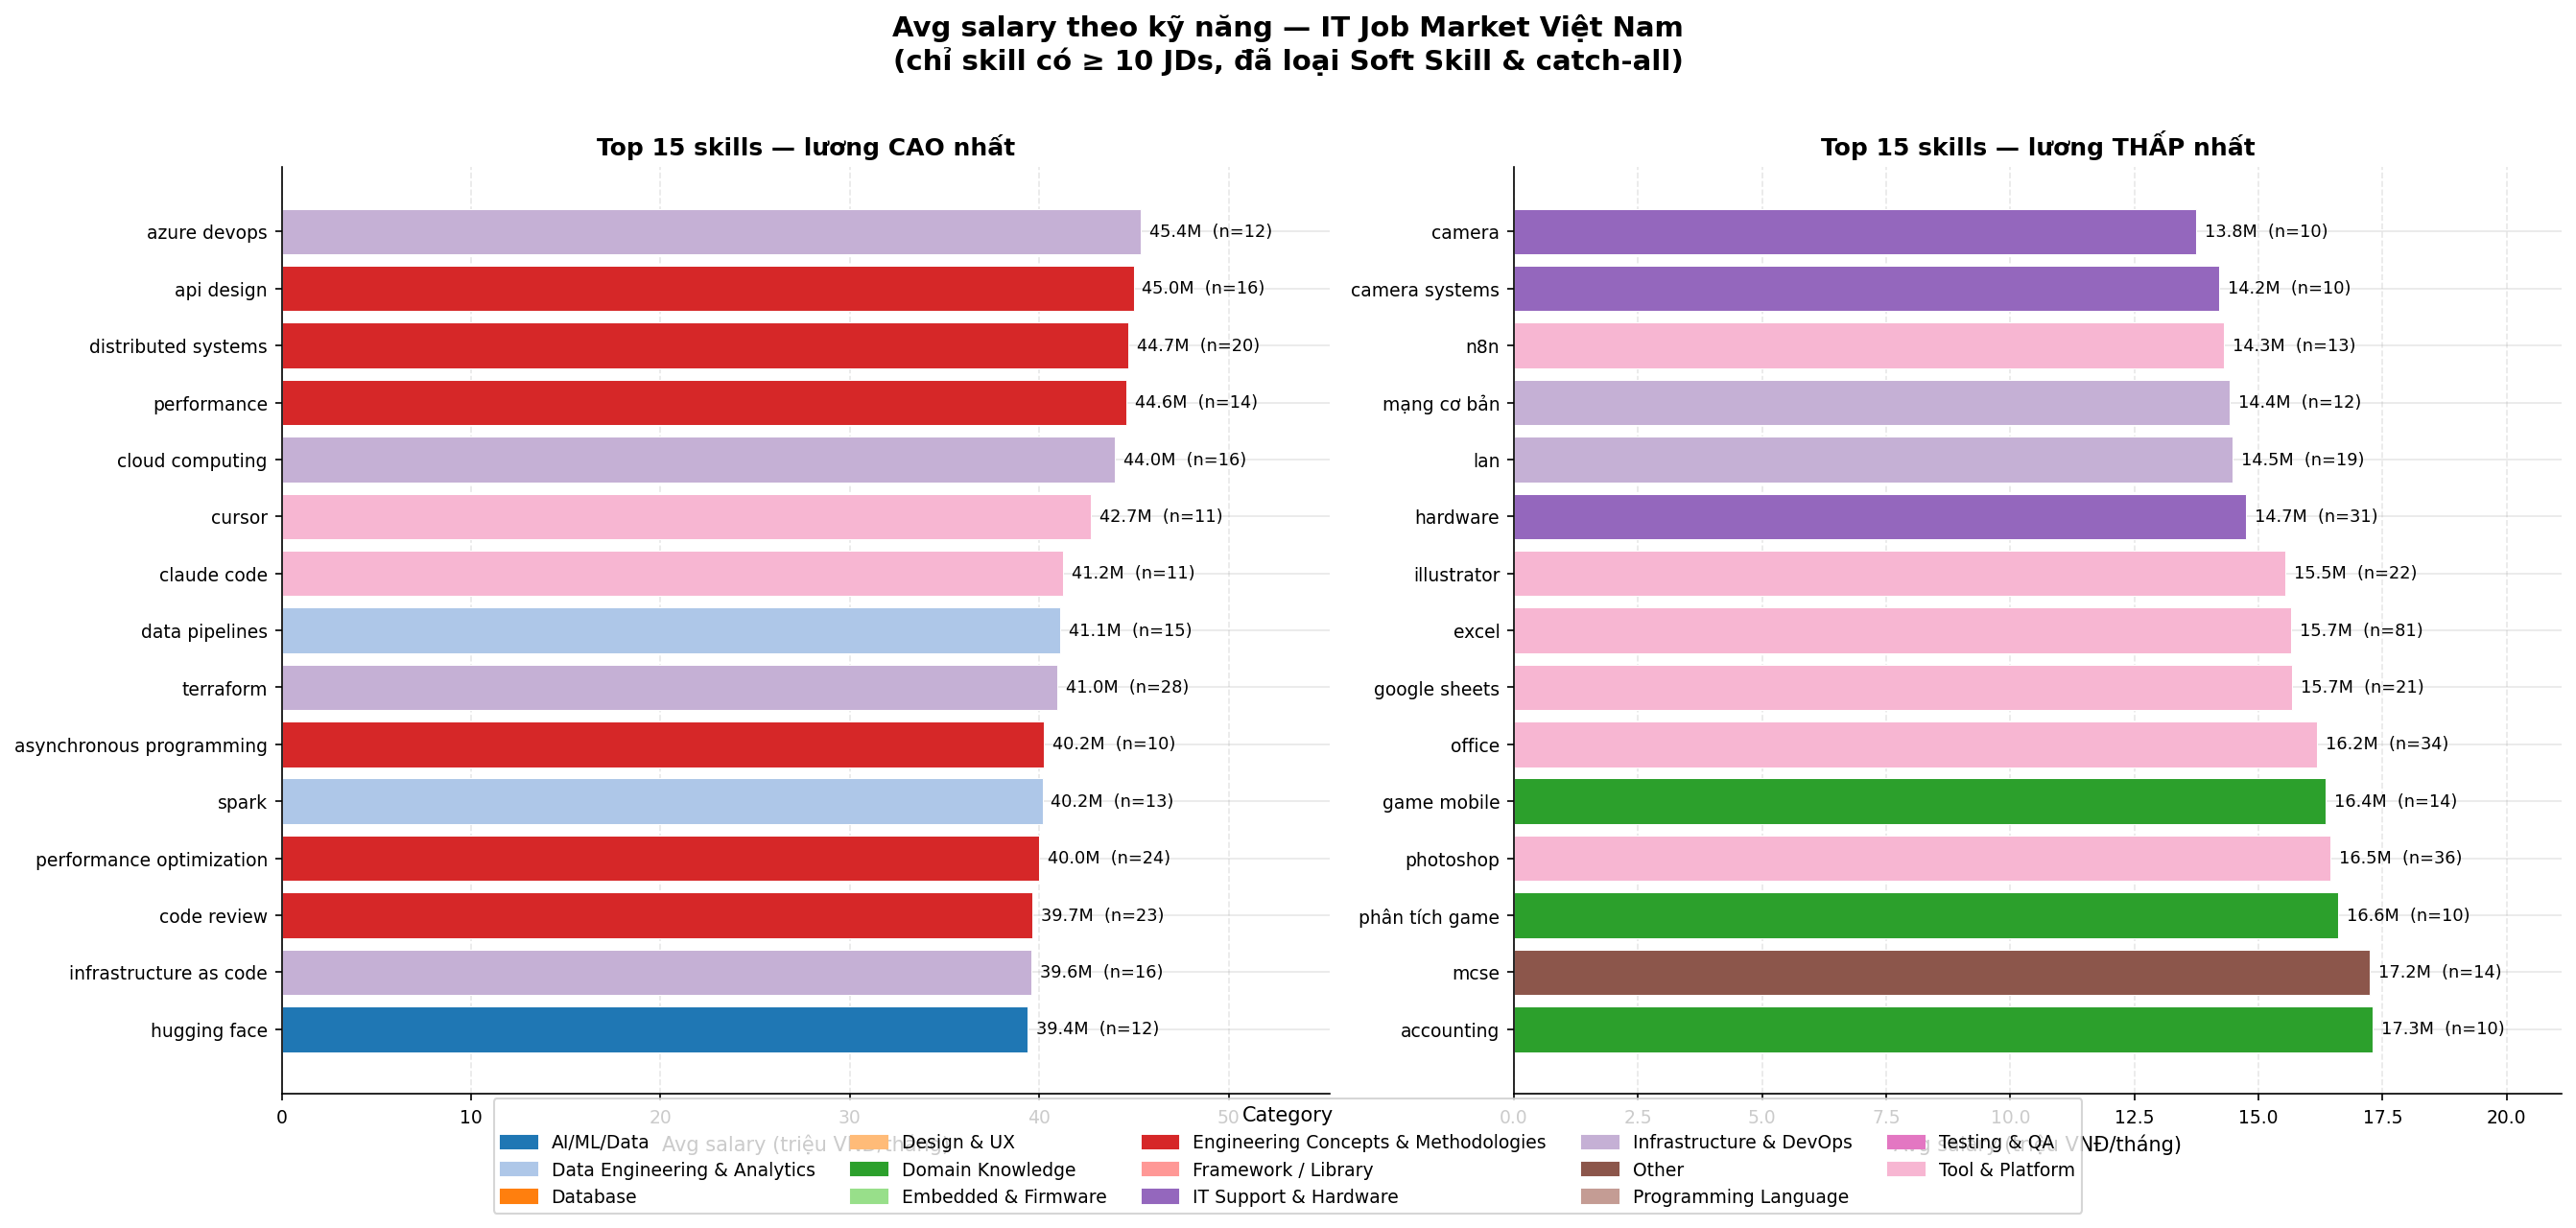

In [81]:
# ============== FIGURE 1: TOP / BOTTOM BAR CHART ==============
top_pay    = skill_salary.nlargest(TOP_N, 'avg_salary').sort_values('avg_salary', ascending=True)
bottom_pay = skill_salary.nsmallest(TOP_N, 'avg_salary').sort_values('avg_salary', ascending=False)

fig1, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, df_plot, title in [
    (axes[0], top_pay,    f'Top {TOP_N} skills — lương CAO nhất'),
    (axes[1], bottom_pay, f'Top {TOP_N} skills — lương THẤP nhất'),
]:
    colors = df_plot['category'].map(cat_color).fillna('gray').values
    sal_m  = df_plot['avg_salary'] / UNIT

    bars = ax.barh(df_plot[SKILL_COL], sal_m,
                   color=colors, edgecolor='white', linewidth=0.5)

    x_max = sal_m.max()
    for bar, s, n in zip(bars, df_plot['avg_salary'], df_plot['n_jobs']):
        ax.text(
            bar.get_width() + x_max * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{s/UNIT:.1f}M  (n={n})',
            va='center', fontsize=8.5
        )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Avg salary (triệu VNĐ/tháng)', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # ĐÃ SỬA DÒNG NÀY (Bỏ / UNIT)
    ax.set_xlim(0, x_max * 1.22) 
    
    ax.tick_params(labelsize=9)

legend_elements = [plt.Rectangle((0,0),1,1, color=cat_color[c], label=c) for c in all_cats]
fig1.legend(handles=legend_elements, title='Category', loc='lower center',
            ncol=5, fontsize=9, title_fontsize=10,
            bbox_to_anchor=(0.5, -0.04), frameon=True)
fig1.suptitle(
    f'Avg salary theo kỹ năng — IT Job Market Việt Nam\n'
    f'(chỉ skill có ≥ {MIN_JOBS} JDs, đã loại Soft Skill & catch-all)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

In [76]:
print(df_jobs[SALARY_COL].describe())
print(df_jobs[SALARY_COL].head())

count      3181.000000
mean        110.047689
std        4920.565537
min           0.000000
25%           0.000000
50%           0.000000
75%          20.500000
max      275000.000000
Name: avg_salary, dtype: float64
0    14.0
1     0.0
2    60.0
3    30.0
4    45.0
Name: avg_salary, dtype: float64


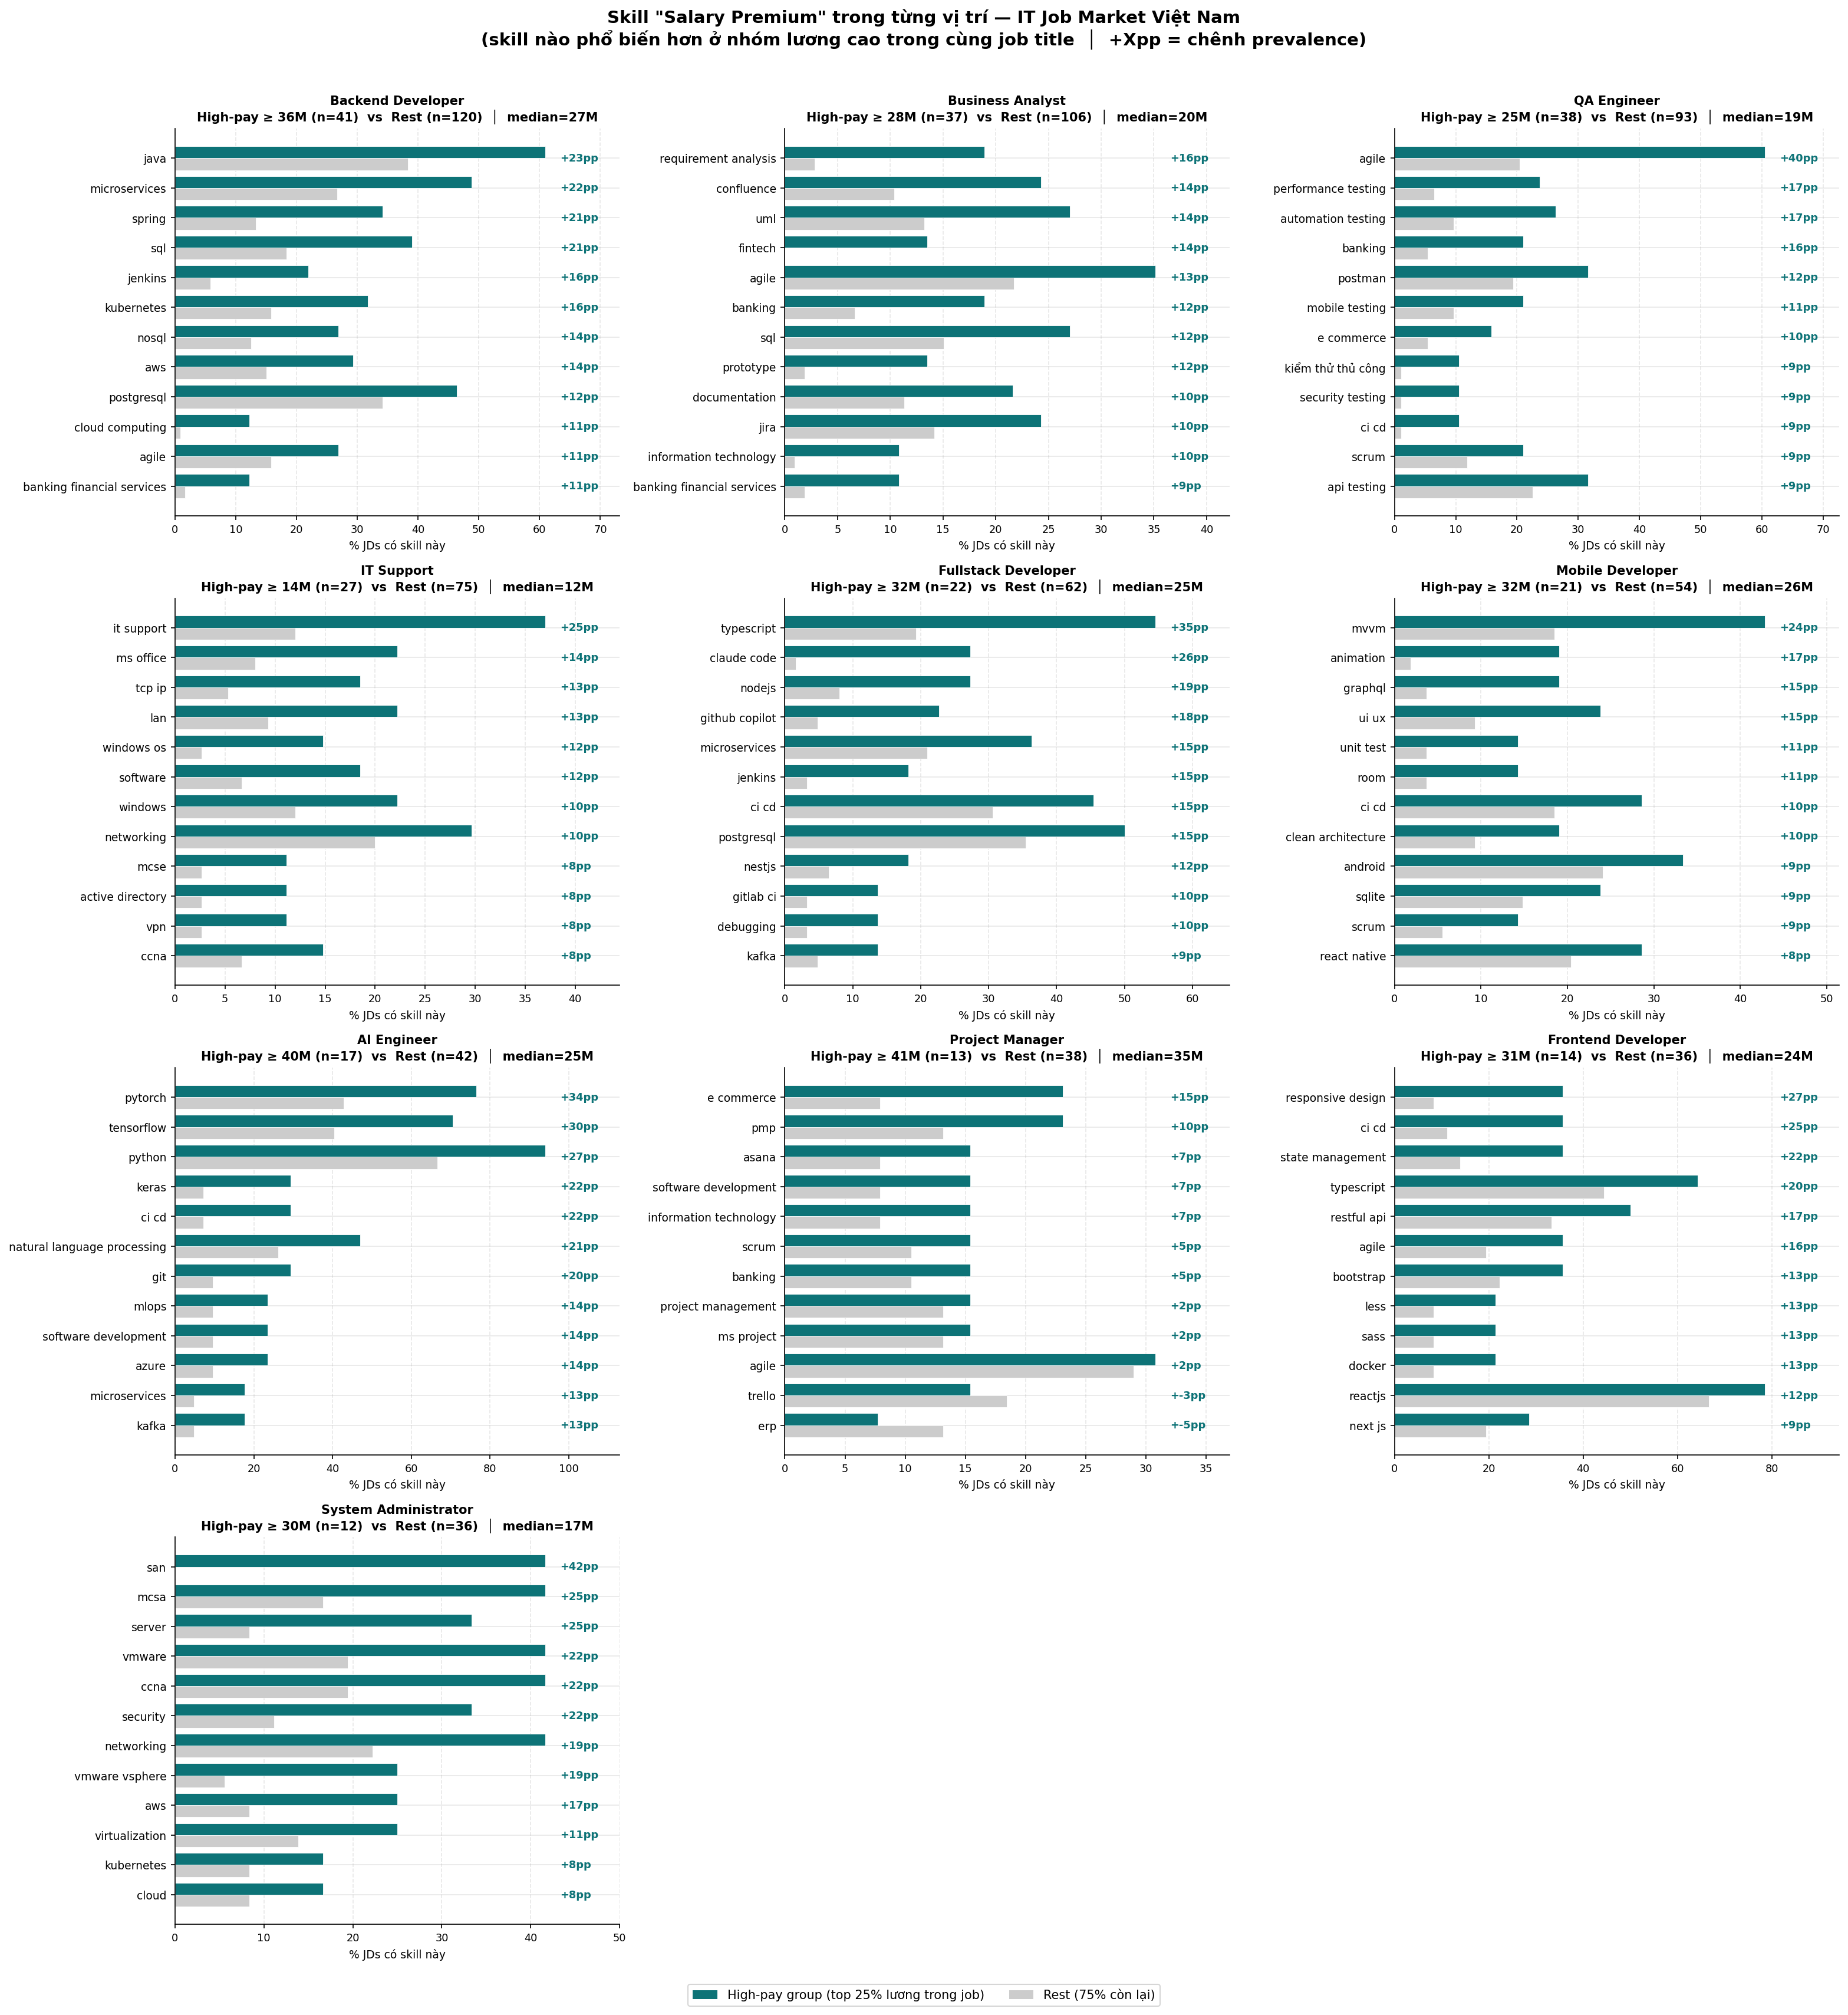

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
from matplotlib.patches import Patch

# ============== CONFIG ==============
TOP_JOBS              = 10     # số job để facet
TOP_SKILLS_PER_JOB    = 12
MIN_JOBS_PER_TITLE    = 40    # job title phải có ≥ 40 JDs có salary
MIN_SKILL_OCCURRENCES = 5     # skill phải xuất hiện ≥ 5 lần trong job đó
HIGH_PAY_QUANTILE     = 0.75  # top 25% lương cao = high-pay group
NCOLS                 = 3

SKILL_COL  = 'final_canonical'
TITLE_COL  = 'standardized_title'
SALARY_COL = 'avg_salary'

# ============== MERGE & FILTER ==============
df_merged = (
    df_skills
    .merge(df_jobs_sal[['job_id', TITLE_COL, SALARY_COL]], on='job_id', how='inner')
    .dropna(subset=[SKILL_COL, TITLE_COL, SALARY_COL])
)
df_merged = df_merged[~df_merged[SKILL_COL].str.lower().str.contains(r'\bother\b', regex=True, na=False)]
df_merged = df_merged[df_merged['category'] != 'Soft Skill']

# Top job titles có đủ sample để split high/rest
title_counts = df_jobs_sal.groupby(TITLE_COL)['job_id'].nunique()
eligible_titles = (
    title_counts[title_counts >= MIN_JOBS_PER_TITLE]
    .sort_values(ascending=False)
    .head(TOP_JOBS)
    .index.tolist()
)

# Color: 2 group tương phản
COLOR_HIGH = '#0d7377'   # teal đậm
COLOR_REST = '#cccccc'   # xám nhạt

# ============== FACETED PLOT ==============
nrows = math.ceil(len(eligible_titles) / NCOLS)
fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 7, nrows * 5.5))
axes = axes.flatten()

for i, title in enumerate(eligible_titles):
    ax = axes[i]

    # Jobs của title này — split theo salary
    jobs_this = df_jobs_sal[df_jobs_sal[TITLE_COL] == title]
    threshold = jobs_this[SALARY_COL].quantile(HIGH_PAY_QUANTILE)

    high_ids = jobs_this[jobs_this[SALARY_COL] >= threshold]['job_id'].unique()
    rest_ids = jobs_this[jobs_this[SALARY_COL] <  threshold]['job_id'].unique()
    n_high, n_rest = len(high_ids), len(rest_ids)

    # Đếm skill prevalence 2 nhóm (drop dup để tránh double-count)
    df_this = df_merged[df_merged[TITLE_COL] == title]
    sk_high = (df_this[df_this['job_id'].isin(high_ids)]
               .drop_duplicates(['job_id', SKILL_COL])
               .groupby(SKILL_COL)['job_id'].nunique())
    sk_rest = (df_this[df_this['job_id'].isin(rest_ids)]
               .drop_duplicates(['job_id', SKILL_COL])
               .groupby(SKILL_COL)['job_id'].nunique())

    sk_df = pd.DataFrame({'n_high': sk_high, 'n_rest': sk_rest}).fillna(0)
    sk_df = sk_df[(sk_df['n_high'] + sk_df['n_rest']) >= MIN_SKILL_OCCURRENCES]
    sk_df['pct_high'] = sk_df['n_high'] / n_high * 100
    sk_df['pct_rest'] = sk_df['n_rest'] / n_rest * 100
    sk_df['delta']    = sk_df['pct_high'] - sk_df['pct_rest']

    # Top N theo delta (skills có premium cao nhất)
    top = sk_df.nlargest(TOP_SKILLS_PER_JOB, 'delta').sort_values('delta', ascending=True)

    # Grouped bar chart
    y = range(len(top))
    ax.barh([v - 0.2 for v in y], top['pct_rest'], height=0.4,
            color=COLOR_REST, edgecolor='white', linewidth=0.4)
    ax.barh([v + 0.2 for v in y], top['pct_high'], height=0.4,
            color=COLOR_HIGH, edgecolor='white', linewidth=0.4)

    ax.set_yticks(list(y))
    ax.set_yticklabels(top.index, fontsize=9)

    # Annotate delta (premium pp)
    x_max = top['pct_high'].max()
    for j, (_, row) in enumerate(top.iterrows()):
        ax.text(
            x_max * 1.04, j,
            f'+{row["delta"]:.0f}pp',
            va='center', fontsize=8.5,
            color='#0d7377', fontweight='bold'
        )

    median_sal = jobs_this[SALARY_COL].median()
    ax.set_title(
        f'{title}\n'
        f'High-pay ≥ {threshold:.0f}M (n={n_high})  vs  Rest (n={n_rest})  '
        f'│  median={median_sal:.0f}M',
        fontsize=10, fontweight='bold', pad=6
    )
    ax.set_xlabel('% JDs có skill này', fontsize=9)
    ax.set_xlim(0, x_max * 1.20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=8.5)

# Ẩn subplot thừa
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# ============== LEGEND & TITLE ==============
legend_elements = [
    Patch(facecolor=COLOR_HIGH, label=f'High-pay group (top {int((1-HIGH_PAY_QUANTILE)*100)}% lương trong job)'),
    Patch(facecolor=COLOR_REST, label='Rest (75% còn lại)')
]
fig.legend(
    handles=legend_elements, loc='lower center', ncol=2,
    fontsize=10, bbox_to_anchor=(0.5, -0.02), frameon=True
)

fig.suptitle(
    f'Skill "Salary Premium" trong từng vị trí — IT Job Market Việt Nam\n'
    f'(skill nào phổ biến hơn ở nhóm lương cao trong cùng job title  │  +Xpp = chênh prevalence)',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

# Salary x Level

=== Phân phối job_level ===
job_level
Nhân viên             898
Trưởng nhóm           321
Intern                110
Senior                 62
Quản lý / Giám sát     47
Trưởng/Phó phòng       26
Junior                  6
Giám đốc                3
Fresher                 1
Name: count, dtype: int64

Missing job_level : 0.00%
Missing avg_salary: 0.00%

Thứ tự ordinal sẽ dùng: ['Junior', 'Mid', 'Senior', 'Lead', 'Manager']

N sau filter: 1379 / 1474
N per level:
job_level_tier
Junior       7
Mid        909
Senior      62
Lead       325
Manager     76
Name: count, dtype: int64

⚠  Levels có n<30 (kết quả test kém ổn định): ['Junior']


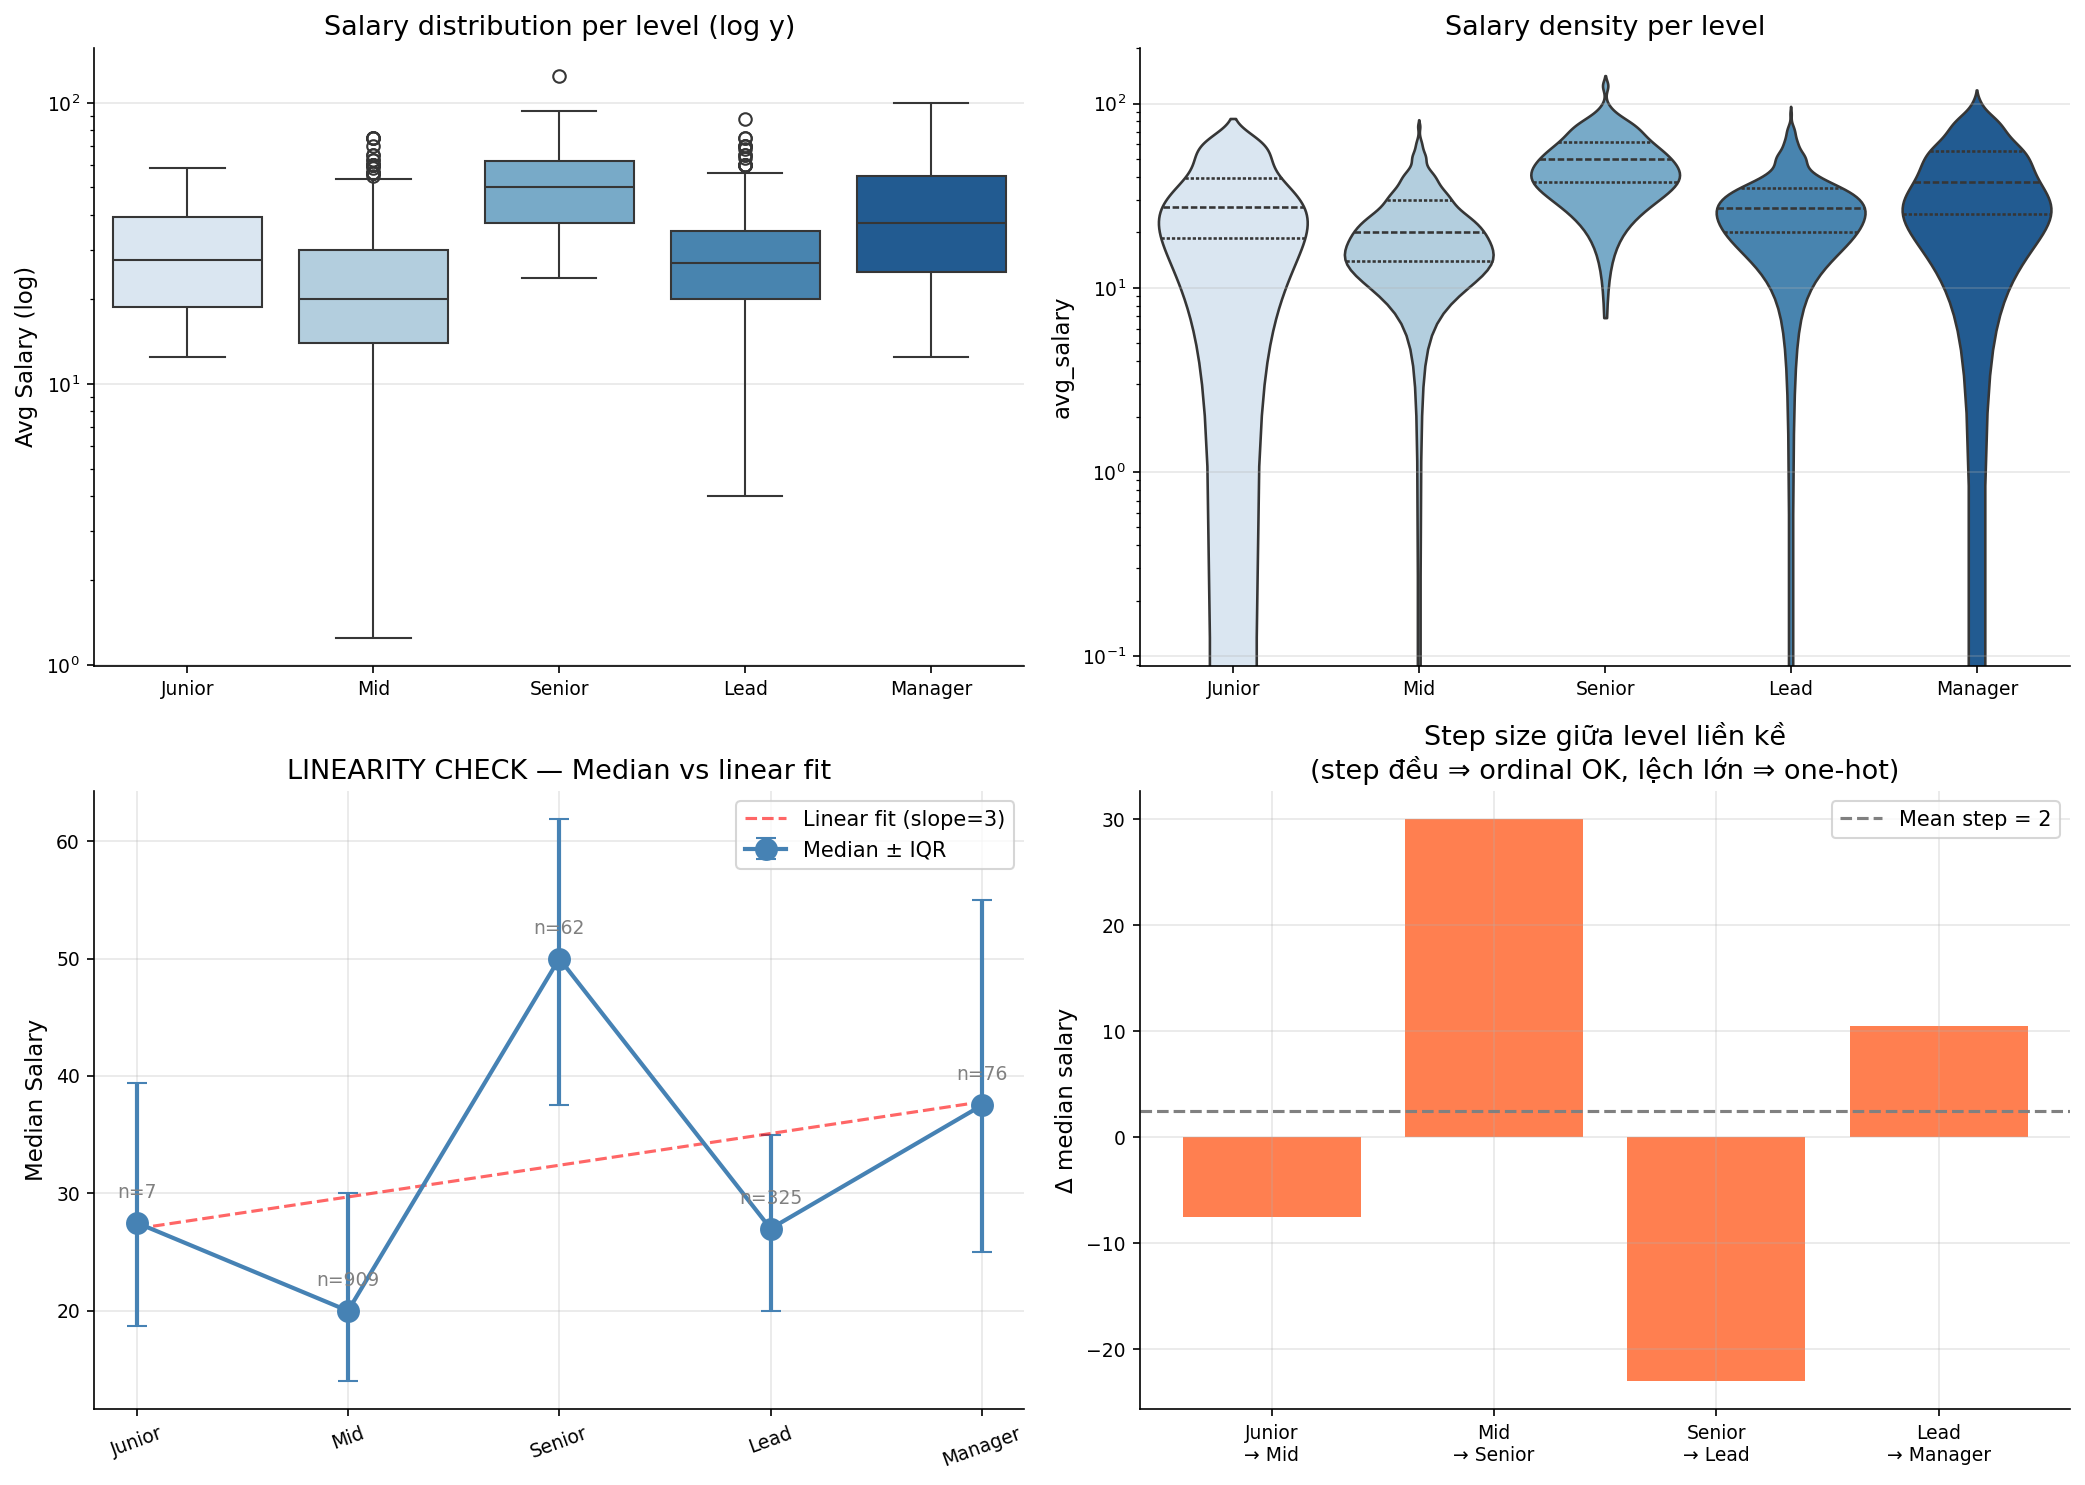


STATISTICAL TESTS

Kruskal-Wallis: H = nan, p = nan
Epsilon² (effect size) = nan
  Interpret: <0.01 negligible | 0.01–0.04 small | 0.04–0.16 medium | >0.16 large

Spearman ρ (level_ord vs salary) = 0.328, p = 6.09e-36
  ρ cao (>0.5) + plot monotonic  ⇒ ordinal encoding OK
  ρ thấp hoặc non-monotonic       ⇒ one-hot encoding

--- Pairwise (adjacent levels), one-sided 'lower < higher' ---
    Junior → Mid     : n too small, skip
       Mid → Senior  : n too small, skip
    Senior → Lead    : n too small, skip
      Lead → Manager : n too small, skip
  (α Bonferroni = 0.0125)


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# =========================================================
# 1. INSPECT — xem job_level có gì
# =========================================================
print("=== Phân phối job_level ===")
print(df_clean['job_level'].value_counts(dropna=False))
print(f"\nMissing job_level : {df_clean['job_level'].isna().mean():.2%}")
print(f"Missing avg_salary: {df_clean['avg_salary'].isna().mean():.2%}")

# =========================================================
# 2. DEFINE ORDINAL ORDER — CHỈNH theo giá trị thực trong df_clean
# =========================================================
# Default IT hierarchy. Bỏ/thêm cho khớp với data thực.
level_order = ['Junior', 'Mid', 'Senior', 'Lead', 'Manager']
level_order = [l for l in level_order if l in df_clean['job_level_tier'].dropna().unique()]
print(f"\nThứ tự ordinal sẽ dùng: {level_order}")

# =========================================================
# 3. CLEAN SUBSET cho phân tích
# =========================================================
df_lvl = (df_clean[df_clean['job_level_tier'].isin(level_order)]
          .dropna(subset=['avg_salary']).copy())
df_lvl['job_level_tier'] = pd.Categorical(df_lvl['job_level_tier'],
                                              categories=level_order, ordered=True)
df_lvl['level_ord'] = df_lvl['job_level_tier'].cat.codes

print(f"\nN sau filter: {len(df_lvl)} / {len(df_clean)}")
print("N per level:")
print(df_lvl['job_level_tier'].value_counts().reindex(level_order))

# Cảnh báo level quá ít sample (sẽ làm test không tin được)
low_n = df_lvl['job_level_tier'].value_counts() < 30
if low_n.any():
    print(f"\n⚠  Levels có n<30 (kết quả test kém ổn định): "
          f"{low_n[low_n].index.tolist()}")

# =========================================================
# 4. VISUALIZATION — 4 panels
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4a. Boxplot log-scale — distribution shape per level
sns.boxplot(data=df_lvl, x='job_level_tier', y='avg_salary',
            order=level_order, ax=axes[0,0], palette='Blues')
axes[0,0].set_yscale('log')
axes[0,0].set_title('Salary distribution per level (log y)')
axes[0,0].set_ylabel('Avg Salary (log)')
axes[0,0].set_xlabel('')

# 4b. Violin — mật độ phân phối
sns.violinplot(data=df_lvl, x='job_level_tier', y='avg_salary',
               order=level_order, ax=axes[0,1], inner='quartile', palette='Blues')
axes[0,1].set_yscale('log')
axes[0,1].set_title('Salary density per level')
axes[0,1].set_xlabel('')

# 4c. LINEARITY CHECK — median ± IQR vs linear fit
stat = (df_lvl.groupby('job_level_tier', observed=True)['avg_salary'] 
        .agg(median='median',
             q25=lambda x: x.quantile(0.25),
             q75=lambda x: x.quantile(0.75),
             n='count')
        .reset_index())

x_pos = np.arange(len(stat))
axes[1,0].errorbar(x_pos, stat['median'],
                   yerr=[stat['median']-stat['q25'],
                         stat['q75']-stat['median']],
                   fmt='o-', capsize=5, linewidth=2, markersize=10,
                   color='steelblue', label='Median ± IQR')

# Linear fit overlay — nếu data linear thì điểm sẽ nằm sát đường này
lin = np.polyfit(x_pos, stat['median'], 1)
axes[1,0].plot(x_pos, np.polyval(lin, x_pos), '--',
               color='red', alpha=0.6, label=f'Linear fit (slope={lin[0]:.0f})')

# Đánh dấu n per level
for xi, ni in zip(x_pos, stat['n']):
    axes[1,0].annotate(f'n={ni}', (xi, stat['median'].iloc[xi]),
                       textcoords="offset points", xytext=(0,12),
                       ha='center', fontsize=9, color='gray')

axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(stat['job_level_tier'], rotation=20)
axes[1,0].set_title('LINEARITY CHECK — Median vs linear fit')
axes[1,0].set_ylabel('Median Salary')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4d. Step size — tăng salary giữa các level liền kề
step = stat['median'].diff().dropna()
axes[1,1].bar(range(len(step)), step.values, color='coral')
axes[1,1].set_xticks(range(len(step)))
axes[1,1].set_xticklabels([f'{a}\n→ {b}'
                           for a,b in zip(level_order[:-1], level_order[1:])],
                          rotation=0, fontsize=9)
axes[1,1].axhline(step.mean(), color='gray', linestyle='--',
                  label=f'Mean step = {step.mean():.0f}')
axes[1,1].set_title('Step size giữa level liền kề\n(step đều ⇒ ordinal OK, lệch lớn ⇒ one-hot)')
axes[1,1].set_ylabel('Δ median salary')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 5. STATISTICAL TESTS
# =========================================================
print("\n" + "="*60)
print("STATISTICAL TESTS")
print("="*60)

# 5a. Kruskal-Wallis (omnibus) — không dùng ANOVA vì salary skewed
groups = [df_lvl[df_lvl['job_level']==l]['avg_salary'].values for l in level_order]
H, p = stats.kruskal(*groups)
k = len(level_order); N = len(df_lvl)
eps_sq = (H - k + 1) / (N - k)   # effect size
print(f"\nKruskal-Wallis: H = {H:.2f}, p = {p:.2e}")
print(f"Epsilon² (effect size) = {eps_sq:.3f}")
print("  Interpret: <0.01 negligible | 0.01–0.04 small | "
      "0.04–0.16 medium | >0.16 large")

# 5b. Spearman — ordinal-encoded level vs salary
rho, p_sp = stats.spearmanr(df_lvl['level_ord'], df_lvl['avg_salary'])
print(f"\nSpearman ρ (level_ord vs salary) = {rho:.3f}, p = {p_sp:.2e}")
print("  ρ cao (>0.5) + plot monotonic  ⇒ ordinal encoding OK")
print("  ρ thấp hoặc non-monotonic       ⇒ one-hot encoding")

# 5c. Pairwise Mann-Whitney với Bonferroni — bước nhảy giữa 2 level liền kề
print("\n--- Pairwise (adjacent levels), one-sided 'lower < higher' ---")
alpha = 0.05 / (k-1)   # Bonferroni
for i in range(k-1):
    a = df_lvl.loc[df_lvl['job_level']==level_order[i], 'avg_salary']
    b = df_lvl.loc[df_lvl['job_level']==level_order[i+1], 'avg_salary']
    if len(a) < 5 or len(b) < 5:
        print(f"  {level_order[i]:>8} → {level_order[i+1]:<8}: n too small, skip")
        continue
    U, pv = stats.mannwhitneyu(a, b, alternative='less')
    # Cliff's delta = (U - n1*n2/2) / (n1*n2/2) — chuẩn, không sampling
    delta = 2*U / (len(a)*len(b)) - 1
    sig = "✓" if pv < alpha else "✗"
    print(f"  {level_order[i]:>8} → {level_order[i+1]:<8}: "
          f"p={pv:.2e}  Cliff's δ={delta:+.2f}  {sig}")
print(f"  (α Bonferroni = {alpha:.4f})")